Vizier Query Version 1
==

Version 1 will query the catalog for a known stellar name and return the WISE measurements. This is for our list of known bright and faint disks for which we already have high contrast imaging data.

In [2]:
#pip install --user photutils

In [3]:
#pip install --upgrade photutils

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy
from astroquery.vizier import Vizier
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
from astropy.coordinates import Angle
from astropy.table import Table

# query hd97048 across all catalogs
v = Vizier(columns=['*', '_r'], catalog=('II/311/wise'))
# query a small region of 2 arcsec around the star to ensure only info for this star is returned
result = v.query_region('HD 97048', radius='2s')
print(result[0])

  _r          WISE         RAJ2000    DEJ2000   eeMaj  ...  ex var   d2M   _2M
                             deg        deg     arcsec ...          arcsec    
----- ------------------- ---------- ---------- ------ ... --- ---- ------ ---
0.219 J110803.28-773917.3 167.013704 -77.654807  0.020 ...   1 0145  0.119  2M


In [5]:
wise_table = result['II/311/wise']
#print(wise_table)
#print(type(wise_table))

In [6]:
df = wise_table.to_pandas()
print(df)

      _r                 WISE     RAJ2000    DEJ2000  eeMaj  eeMin  Im  W1mag  \
0  0.219  J110803.28-773917.3  167.013704 -77.654807   0.02  0.016  Im   5.02   

   e_W1mag  W2mag  ...  W4mag  e_W4mag   Jmag   Hmag   Kmag   ccf  ex   var  \
0    0.072    4.3  ... -1.309    0.013  7.267  6.665  5.941  hhhh   1  0145   

     d2M  _2M  
0  0.119   2M  

[1 rows x 23 columns]


In [7]:
W1mag = df._get_value(0, 'W1mag')
print(W1mag)
print(type(wise_table))

5.02
<class 'astropy.table.table.Table'>


In [8]:
# query one star

#def W1mag(str):
    #star = Vizier.query_object(str)
    #wise_table = star['II/311/wise']
    #W1mag = wise_table['W1mag']
    #mean = np.mean(W1mag)
    #return mean

#W1mag("hd97048")

In [9]:
# query list of stars

def wise_mag(stars):
    for str in stars:
        v = Vizier(columns=['*', '_r'], catalog=('II/311/wise'))
        star = v.query_region(str, radius='2s')
        wise_table = star["II/311/wise"]
        W1 = wise_table['W1mag']
        W1mag = np.round(W1, 3)
        W2 = wise_table['W2mag']
        W2mag = np.round(W2, 3)
        W3 = wise_table['W3mag']
        W3mag = np.round(W3, 3)
        W4 = wise_table['W4mag']
        W4mag = np.round(W4, 3)
        magnitudes = [W1mag, W2mag, W3mag, W4mag]
        print(magnitudes)
    
stars = ["hd97048", "hd31293", "hd31648"]
wise_mag(stars)

[<MaskedColumn name='W1mag' dtype='float32' length=1>
5.02, <MaskedColumn name='W2mag' dtype='float32' length=1>
4.3, <MaskedColumn name='W3mag' dtype='float32' length=1>
1.404, <MaskedColumn name='W4mag' dtype='float32' length=1>
-1.309]
[<MaskedColumn name='W1mag' dtype='float32' length=1>
3.254, <MaskedColumn name='W2mag' dtype='float32' length=1>
2.142, <MaskedColumn name='W3mag' dtype='float32' length=1>
0.682, <MaskedColumn name='W4mag' dtype='float32' length=1>
-1.713]
[<MaskedColumn name='W1mag' dtype='float32' length=1>
4.913, <MaskedColumn name='W2mag' dtype='float32' length=1>
3.726, <MaskedColumn name='W3mag' dtype='float32' length=1>
1.612, <MaskedColumn name='W4mag' dtype='float32' length=1>
0.076]


In [10]:
# write a function which takes a star name from a list of stars, queries the WISE catalog and the WISE magnitudes for the star
def wise_mag2(stars):
    for star_name in stars:
        # query WISE catalog for the star
        v = Vizier(columns=['*', '_r'], catalog=('II/311/wise'))
        
        # query a small region of 2 arcsec around the star to ensure only info for this star is returned
        star_result = v.query_region(star_name, radius='2s')
        
        # return the wise data table for the star
        wise_table = star_result['II/311/wise']
        
        # convert the astropy table to a pandas data frame
        df = wise_table.to_pandas()
        
        # extract the wise magnitudes from the table
        #W1mag = df._get_value(0, 'W1mag')
        #W2mag = df._get_value(0, 'W2mag')
        #W3mag = df._get_value(0, 'W3mag')
        #W4mag = df._get_value(0, 'W4mag')
        magnitudes = df[['W1mag', 'W2mag', 'W3mag', 'W4mag']].iloc[0].tolist()
        
        #print the magnitudes
        print(magnitudes)
    
stars = ['GG Tau', 'UX Tau', 'LkHa 330', 'RX J1852.3-3700', 'AB Aur', 'Ak Sco', 'HD97048', 'HD31648', 'HD31293']
wise_mag2(stars)

[6.504000186920166, 6.078000068664551, 4.084000110626221, 1.968999981880188]
[6.921999931335449, 6.581999778747559, 5.695000171661377, 2.1110000610351562]
[6.072000026702881, 5.2170000076293945, 4.322999954223633, 1.2300000190734863]
[8.782999992370605, 8.647000312805176, 6.927000045776367, 3.1089999675750732]
[3.253999948501587, 2.1419999599456787, 0.6819999814033508, -1.7130000591278076]
[5.589000225067139, 4.800000190734863, 3.0320000648498535, 0.8880000114440918]
[5.019999980926514, 4.300000190734863, 1.4040000438690186, -1.309000015258789]
[4.913000106811523, 3.7260000705718994, 1.6119999885559082, 0.07599999755620956]
[3.253999948501587, 2.1419999599456787, 0.6819999814033508, -1.7130000591278076]


RX J1604.3-2130 - image, no data, in list, cant query

In [11]:
# read in file with list of star names
# query each star in VizieR

# open the file and read in the data
filedata = open('starlist.txt', 'r')
starnames = filedata.readlines()

with open('starlist.txt') as starlist:
    lines = starlist.read().splitlines()
    
# Define a list to hold all the star names
StarID = []
# Append the list to hold the names from the file.
for line in lines:
    StarID.append(line)
    
print(StarID)

wise_mag2(StarID)

['HD31648', 'HD34282', 'HD36112', 'HD97048', 'HD100453', 'HD100546', 'HD135344B', 'HD139614', 'HD142527', 'HD142666', 'HD143006', 'HD144432', 'HD163296', 'HD169142', 'HD179218', 'TW Hya', 'PDS 70', 'EM* SR21', 'LkCa15', 'V4046 Sgr', 'PDS 66', 'GM Aur', 'RX J1615.3-3255', 'V1247 Ori', 'T Cha', 'DoAr 44', 'DZ Cha', 'AS209', 'IM Lup', 'MY Lup', 'RU Lup', 'RY Lup', 'CI Tau', 'CQ Tau', 'CS Cha', 'CV Cha', 'Sz 111', 'DI Cha', 'IRAS 08267-3336', 'SY Cha', 'VZ Cha', 'EX Lup', 'SZ Cha', 'GW Lup', '2MASS J16083070-3828268', 'V718 Sco', 'GG Tau', 'UX Tau', 'LkHa 330', 'AB Aur', 'Ak Sco', '2MASS_J18521730-3700119']
[4.913000106811523, 3.7260000705718994, 1.6119999885559082, 0.07599999755620956]
[6.76800012588501, 6.289000034332275, 4.425000190734863, 1.940000057220459]
[4.598999977111816, 3.562000036239624, 2.121000051498413, -0.17499999701976776]
[5.019999980926514, 4.300000190734863, 1.4040000438690186, -1.309000015258789]
[4.757999897003174, 3.388000011444092, 1.4529999494552612, -1.35500001907

In [12]:
#def write_to_file(file_path, content):
 #   with open(file.path, 'w') as f:
  #      f.write(content)
        
#file_path = 'magnitudes.txt'
#data = [wise_mag2(StarID)]

#write_to_file(file_path, data)

from contextlib import redirect_stdout

with open('magnitudes.txt', 'w') as f:
    with redirect_stdout(f):
        wise_mag2(StarID)

In [13]:
f = open('magnitudes.txt', 'r')
read = f.readlines()

with open("magnitudes.txt") as data:
    lines = data.read().splitlines()

wise1 = []
for line in lines:
    Columns = line.split(',')
    wise1.append(Columns[0])
    
char1 = '['
W1_corr = [ele.replace(char1, '') for ele in wise1]

W1 = []
for item in W1_corr:
    W1.append(float(item))
#print(W1)

# WISE 2 magnitudes
wise2 = []
for line in lines:
    Columns = line.split(',')
    wise2.append(Columns[1])
    
W2 = []
for item in wise2:
    W2.append(float(item))
    
# WISE 3 magnitudes
wise3 = []
for line in lines:
    Columns = line.split(',')
    wise3.append(Columns[2])
    
W3 = []
for item in wise3:
    W3.append(float(item))

# WISE 4 magnitudes
wise4 =[]
for line in lines:
    Columns = line.split(',')
    wise4.append(Columns[3])
    
char2 = ']'
W4_corr = [ele.replace(char2, '') for ele in wise4]

W4 = []
for item in W4_corr:
    W4.append(float(item))

### Converting WISE magnitudes to flux density

The source flux density, in Janksy (Jy) units, is computed from the calibrated WISE magnitudes, $ m_{vega} $ using:
$$ F_v[Jy] = F_{v0} \times 10^{(-m_{vega}/2.5)} $$

where $ F_{v^0} $ is the zero magnitude flux density corresponding to the constant that gives the same response as that of Vega. *For most sources, the zero magnitude flux density, derived using a constant power-law spectra, is appropriate and may be used to convert WISE magnitudes to flux density units.* The zero magnitude flux density for each WISE band is:

| Band | $F_{v^0}$ [Jy] |
| --- | --- |
| W1 | 309.540 |
| W2 | 171.787 |
| W3 | 31.674 |
| W4 | 8.363 |

Faint disks:
HD179218
DZ Cha
HD163296
HD31648
Sz71
CI Tau
AS209
RU Lup

In [14]:
# Define an array for the magnitudes for each WISE band
W1_mag = np.array(W1)
W2_mag = np.array(W2)
W3_mag = np.array(W3)
W4_mag = np.array(W4)

# Convert the magnitudes to fluxes using the formula and correct conversion factor for each band.
W1_flux_density = (309.540 * 10**(-W1_mag/2.5))
W2_flux_density = (171.787 * 10**(-W2_mag/2.5))
W3_flux_density = (31.674 * 10**(-W3_mag/2.5))
W4_flux_density = (8.363 * 10**(-W4_mag/2.5))

# Frequency of each of the WISE bands
W1_freq = 8.95e-13
W2_freq = 6.52e-13
W3_freq = 2.59e-13
W4_freq = 1.36e-13

W1 = W1_flux_density * W1_freq

# Multilpy the flux density by the frequency to find flux
W1_flux = np.log10(W1_flux_density * W1_freq)
W2_flux = np.log10(W2_flux_density * W2_freq)
W3_flux = np.log10(W3_flux_density * W3_freq)
W4_flux = np.log10(W4_flux_density * W4_freq)

print(W1)

# wavelength values for each of the WISE bands
W1_wavelength = np.log10(3.35)
W2_wavelength = np.log10(4.6)
W3_wavelength = np.log10(11.6)
W4_wavelength = np.log10(22.1)

# Calculate the slopes between the first two fluxes and between the last two fluxes
slope1 = (W3_flux - W1_flux) / (W3_wavelength - W1_wavelength)
slope2 = (W4_flux - W3_flux) / (W4_wavelength - W3_wavelength)
slope3 = (W2_flux - W1_flux) / (W2_wavelength - W1_wavelength)
slope4 = (W3_flux - W2_flux) / (W3_wavelength - W2_wavelength)
print(np.round(slope1, 4))
print(np.round(slope2, 4))
print(np.round(slope3, 4))
print(np.round(slope4, 4))

[3.00150984e-12 5.43675501e-13 4.00811176e-12 2.71981786e-12
 3.46210197e-12 5.78282072e-12 2.65546029e-12 1.23976610e-12
 5.50731274e-12 2.71981786e-12 1.29819470e-12 2.10348732e-12
 9.12304417e-12 1.10800025e-12 3.10842085e-12 4.00073588e-13
 1.70663169e-13 1.01330412e-12 2.79601763e-13 3.92048463e-13
 6.48245868e-13 1.24434166e-13 1.07483020e-13 8.03414875e-13
 1.27450000e-12 5.30810804e-13 1.45794115e-13 6.82558454e-13
 4.64878791e-13 1.74316987e-13 1.12134658e-12 9.21594226e-13
 5.40181586e-13 2.06890166e-12 1.54361760e-13 1.48367857e-12
 4.51377292e-14 1.93259075e-12 1.77394329e-13 1.20154483e-13
 3.19845223e-13 1.46197422e-13 4.06386965e-13 1.12859900e-13
 1.44058802e-13 1.35687480e-12 6.93329595e-13 4.71780342e-13
 1.03214284e-12 1.38337472e-11 1.61042211e-12 8.49845182e-14]
[-0.3859 -1.0963 -0.9962 -0.1523 -0.3829  0.7939 -1.8823 -0.0722 -0.6691
 -0.3035 -1.5404 -0.2249 -0.5097 -0.4088  0.5448 -0.9302 -1.1207 -0.4726
 -1.5063 -1.2297 -0.9695 -1.1333 -1.0881 -1.2928 -1.9565 -0.

In [15]:
from matplotlib.colors import SymLogNorm
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredSizeBar
import matplotlib.transforms as transforms

# Load FITS image data
fits_image = get_pkg_data_filename('TW_Hya_SPHERE_2015-04-01_H.fits')
image_data = fits.getdata(fits_image, ext=0)
image_arr = image_data[1]

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(image_arr, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))

ImportError: cannot import name 'AnchoredSizeBar' from 'matplotlib.offsetbox' (C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\offsetbox.py)

<ipython-input-16-736f6a1db851>:9: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image_arr, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


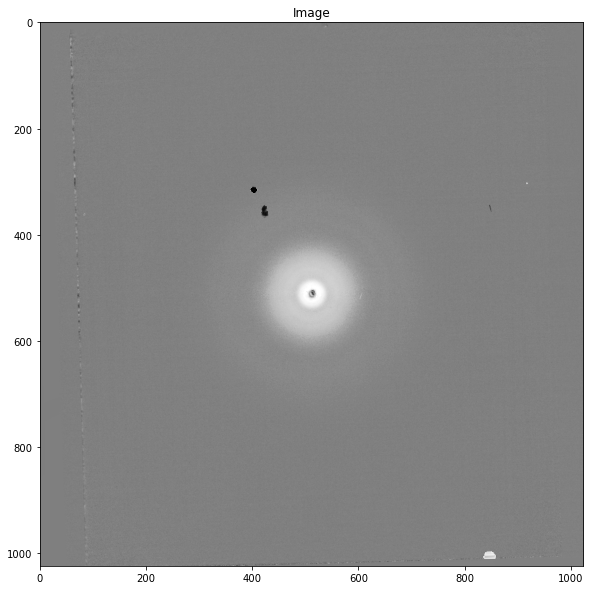

In [16]:
from matplotlib.colors import SymLogNorm
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename

fits_image = get_pkg_data_filename('TW_Hya_SPHERE_2015-04-01_H.fits')
image_data = fits.getdata(fits_image, ext=0)
image_arr = image_data[1]
plt.figure(figsize=(10,10))
plt.imshow(image_arr, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
plt.title('Image')
plt.savefig('display_image_TW_Hya.png', transparent=True)
plt.show()

In [17]:
hdul = fits.open(fits_image)
hdul.info()

Filename: TW_Hya_SPHERE_2015-04-01_H.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      56   (1024, 1024, 6)   float32   


<ipython-input-18-c4916a84b428>:32: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image_arr, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


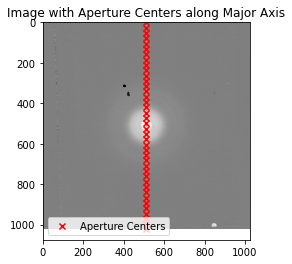

In [18]:
def generate_aperture_coordinates(image, angle_major_axis, num_apertures):
    # Get the center of the image
    center_y, center_x = np.array(image.shape) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image.shape) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)

    return x_coordinates, y_coordinates

# Example usage:
# Assuming you have an image stored as a numpy array (replace 'your_image.npy' with your actual file or array)
#image = image_arr

# Set the angle for the major axis (replace 45 with your desired angle)
angle_major_axis = 90

# Set the number of apertures
num_apertures = 40

# Generate aperture coordinates
x_coordinates, y_coordinates = generate_aperture_coordinates(image_arr, angle_major_axis, num_apertures)

# Visualize the image and the apertures
plt.imshow(image_arr, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centers')
plt.title('Image with Aperture Centers along Major Axis')
plt.legend()
plt.savefig('apertures.jpg')
plt.show()

In [19]:
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.aperture import ApertureStats
import matplotlib.pyplot as plt
import numpy as np

Function which looks at filenames of fits files for stars, sorts through to last letter before .fits and querys 2MASS catalog for the magnitude of the star in this band.
List of stars? Stores results in list?

Need to have the master function above include code to query the 2MASS catalog for the star, get the magnitude for the correct band and divide the brightness value by this magnitude and return this. Create file/list and append these values to the list each time.

Make figure sizes bigger
Angles of disks

<ipython-input-30-86b22b2042fb>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


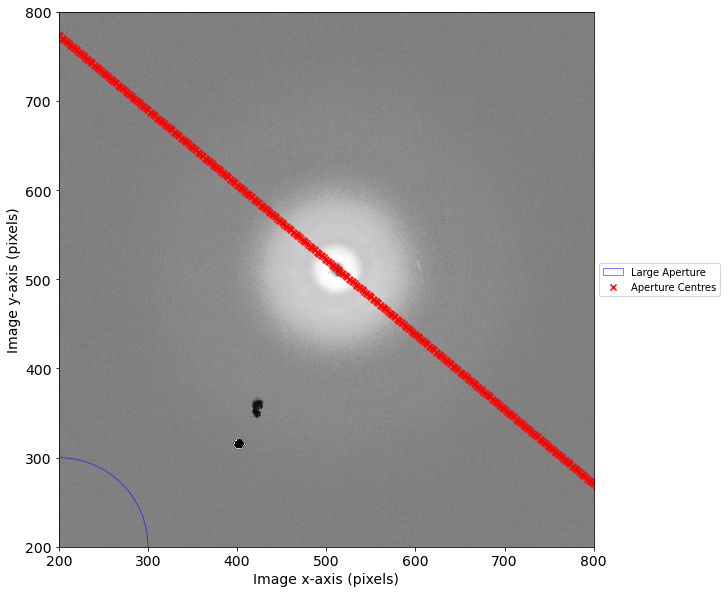

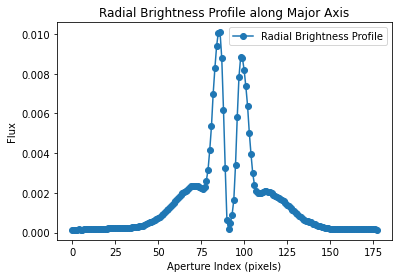

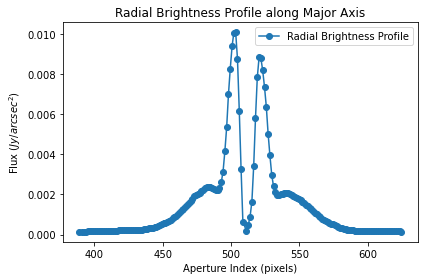

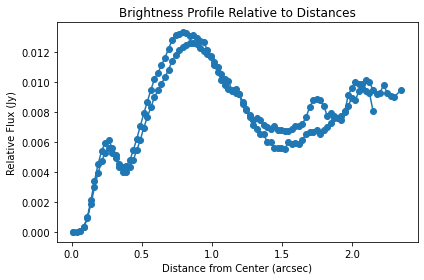

Hmag    0.008119
Name: 0, dtype: float32


In [30]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    plt.gca().invert_yaxis()
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.xlabel('Image x-axis (pixels)', fontsize=14)
    plt.ylabel('Image y-axis (pixels)', fontsize=14)
    plt.xlim(200, 800)
    plt.ylim(200, 800)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.savefig('image_twhya.jpg')
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the noise
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux (Jy)')
    plt.title('Brightness Profile Relative to Distances')
    plt.tight_layout()
    plt.savefig('rel_brightness_hd97048.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        brightness_profile.append(flux)
        aperture_values.append(y)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index (pixels)')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index (pixels)')
    plt.ylabel('Flux ($Jy/arcsec^2$)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.tight_layout()
    plt.savefig('brightness_profile_hd97048.jpg')
    plt.show()
    
    # Function 5: Plot the flux of the disk relative to the distance of the apertures
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    #Function 6: Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'TW Hya'
file_path = 'TW_Hya_SPHERE_2015-04-01_H.fits'
angle_major_axis = 140  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00011517757495475306


<ipython-input-27-4524736b619c>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


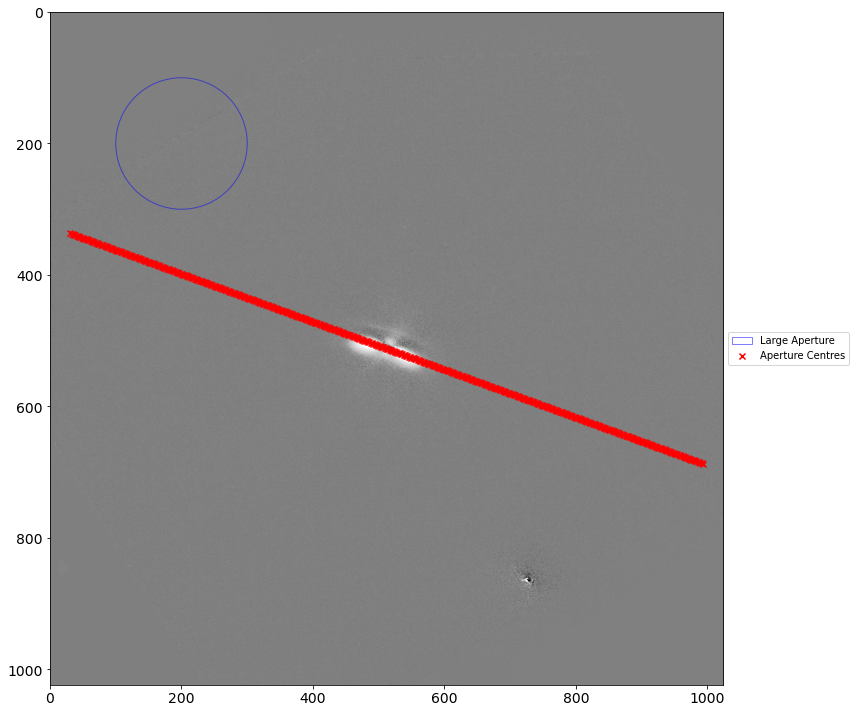

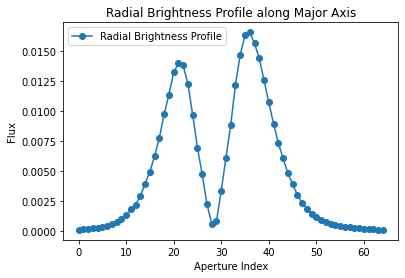

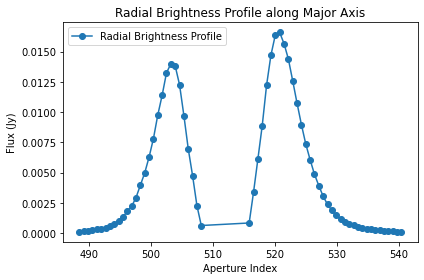

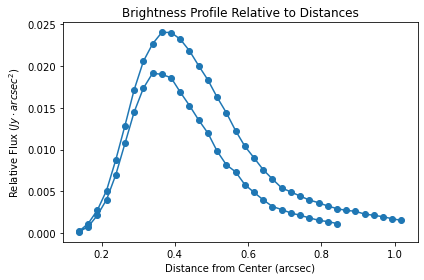

Hmag    0.019428
Name: 0, dtype: float32


In [27]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.tight_layout()
    plt.savefig('image_2MASSJ1608.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.tight_layout()
    plt.savefig('rel_brightness_2MASSJ1608.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.tight_layout()
    plt.savefig('brightness_profile_2MASSJ1608.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = '2MASS J16083070-3828268'
file_path = '2MASS_J16083070-3828268_SPHERE_2017-06-18_H.fits'
angle_major_axis = 20  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00027213814491277644


<ipython-input-69-fbe9cf11c6a7>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


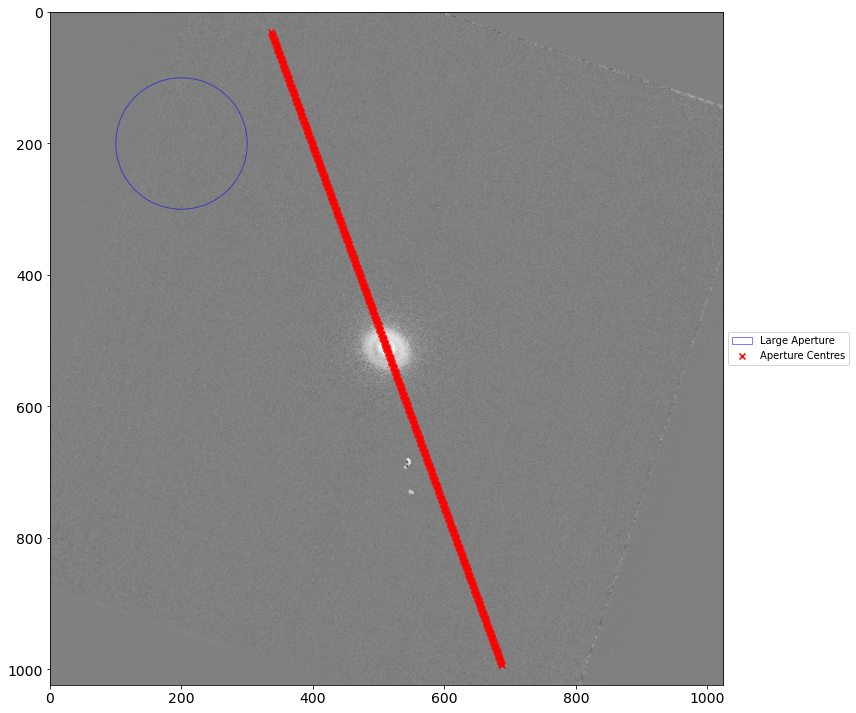

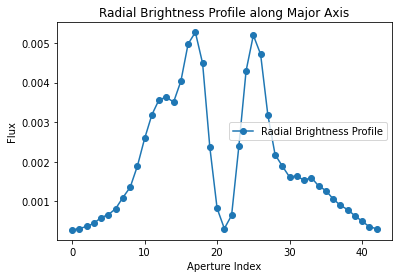

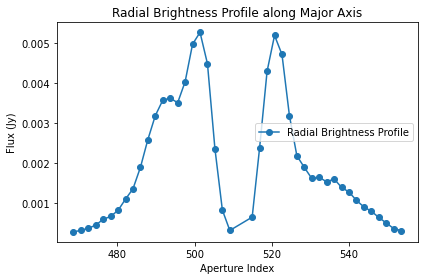

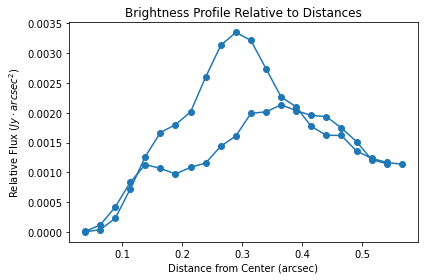

Hmag    0.006653
Name: 0, dtype: float32


In [69]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.tight_layout()
    plt.savefig('image_2MASSJ18521.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.tight_layout()
    plt.savefig('rel_brightness_2MASSJ18521.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.tight_layout()
    plt.savefig('brightness_profile_2MASSJ18521.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = '2MASS J18521730-3700119'
file_path = '2MASS_J18521730-3700119_SPHERE_2017-05-16_H.fits'
angle_major_axis = 70  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00040689105784105214


<ipython-input-70-c84711809c9e>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


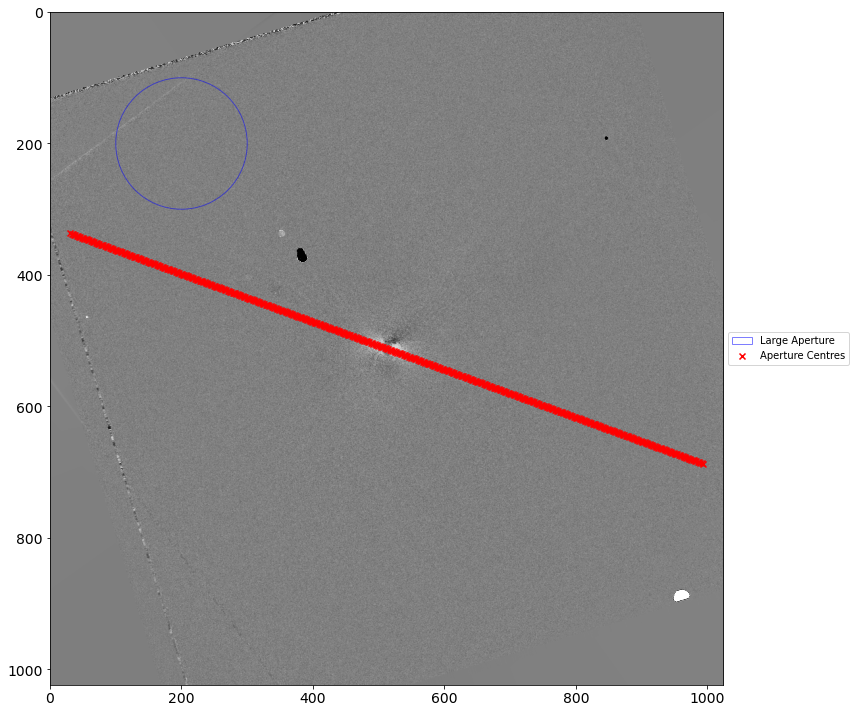

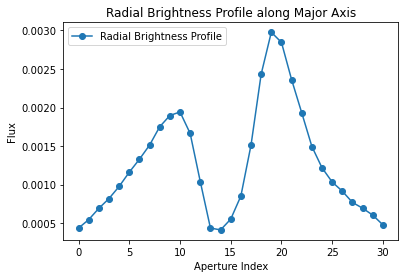

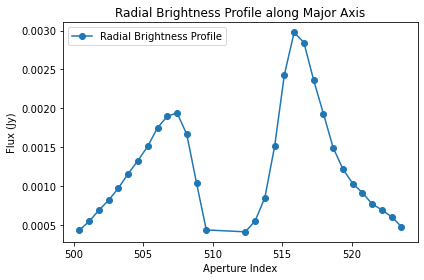

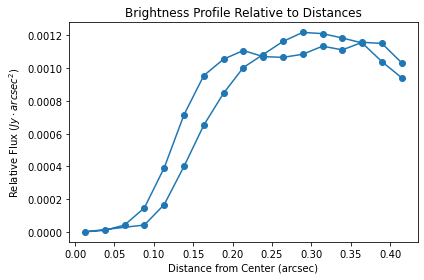

Kmag    0.000748
Name: 0, dtype: float32


In [70]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.tight_layout()
    plt.savefig('image_AS209.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.tight_layout()
    plt.savefig('rel_brightness_AS209.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.tight_layout()
    plt.savefig('brightness_profile_AS_209.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'AS 209'
file_path = 'As_209_SPHERE_2016-03-11_K.fits'
angle_major_axis = 20  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00014060784391917166


<ipython-input-71-0842c7739ef7>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


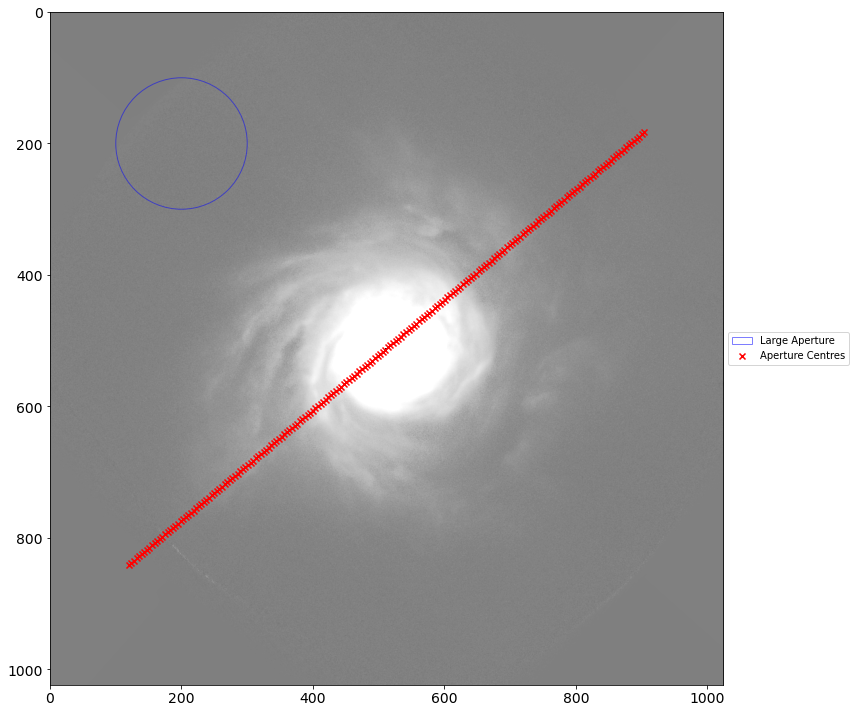

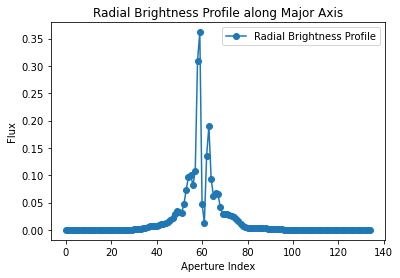

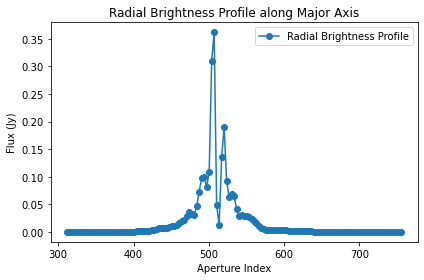

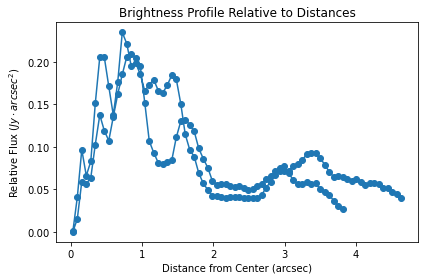

Hmag    0.009257
Name: 0, dtype: float32


In [71]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.tight_layout()
    plt.savefig('image_AB_Aur.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.tight_layout()
    plt.savefig('rel_brightness_AB_Aur.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.tight_layout()
    plt.savefig('brightness_profile_AB_Aur.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'AB Aur'
file_path = 'AB_Aur_SPHERE_2019-12-18_H.fits'
angle_major_axis = 140  # angle of the major axis
num_apertures = 200
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00010415062486680471


<ipython-input-72-d39815211e4d>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


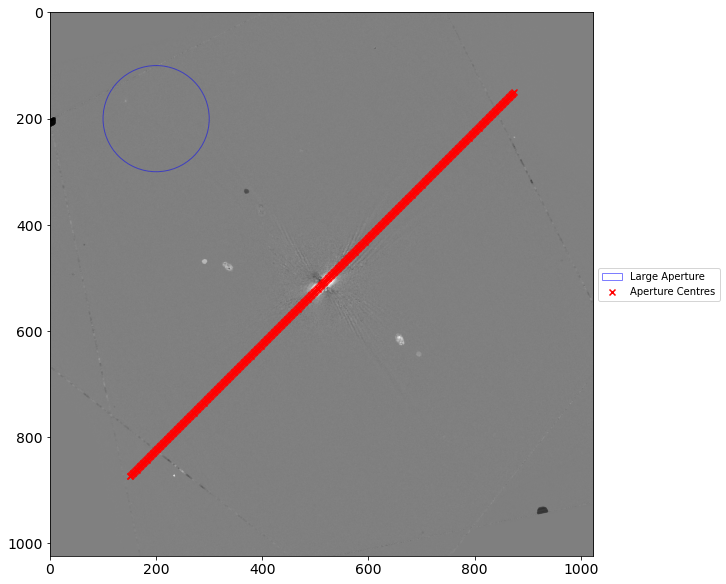

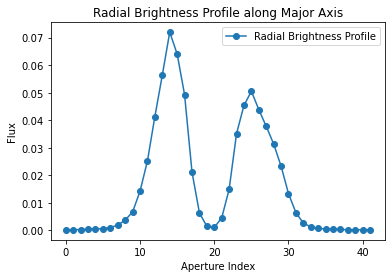

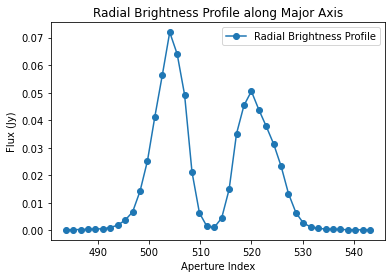

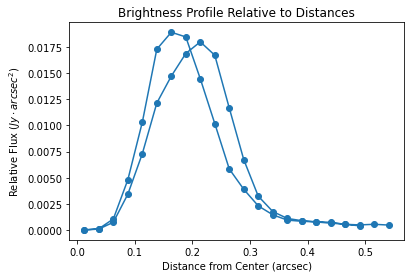

Hmag    0.003594
Name: 0, dtype: float32


In [72]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_AK_Sco.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        if dist_arcsec > 4:
            continue
        
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_AK_Sco.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        if y > 800:
            continue
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_AK_Sco.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'AK Sco'
file_path = 'Ak_Sco_SPHERE_2016-05-27_H.fits'
angle_major_axis = 135  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

<ipython-input-24-b6ce248fe4c4>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


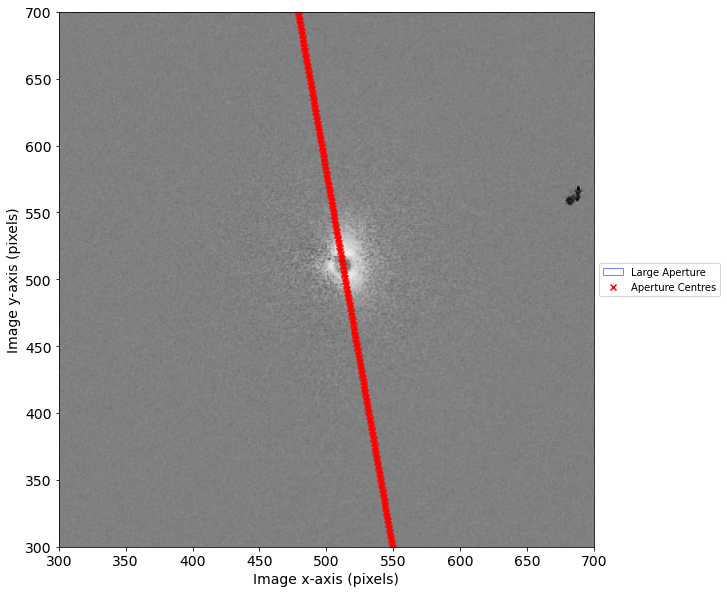

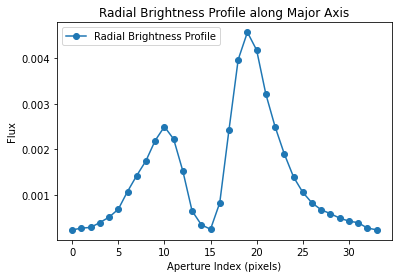

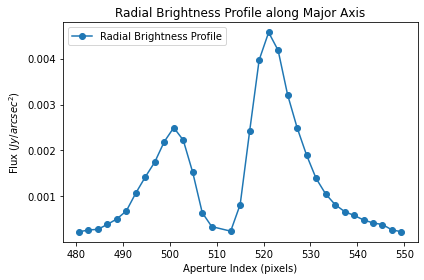

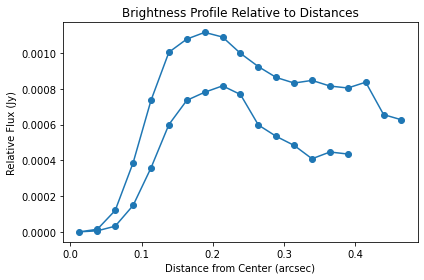

Hmag    0.001415
Name: 0, dtype: float32


In [24]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    plt.gca().invert_yaxis()
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.xlabel('Image x-axis (pixels)', fontsize=14)
    plt.ylabel('Image y-axis (pixels)', fontsize=14)
    plt.xlim(300, 700)
    plt.ylim(300, 700)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.savefig('image_CI_Tau.jpg')
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the noise
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux (Jy)')
    plt.title('Brightness Profile Relative to Distances')
    plt.tight_layout()
    plt.savefig('rel_brightness_CI_Tau.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        brightness_profile.append(flux)
        aperture_values.append(y)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index (pixels)')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index (pixels)')
    plt.ylabel('Flux ($Jy/arcsec^2$)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.tight_layout()
    plt.savefig('brightness_profile_CI_Tau.jpg')
    plt.show()
    
    # Function 5: Plot the flux of the disk relative to the distance of the apertures
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    #Function 6: Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'CI Tau'
file_path = 'CI_Tau_SPHERE_2018-01-02_H.fits'
angle_major_axis = 100  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00011361983971924285


<ipython-input-73-827896ced495>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


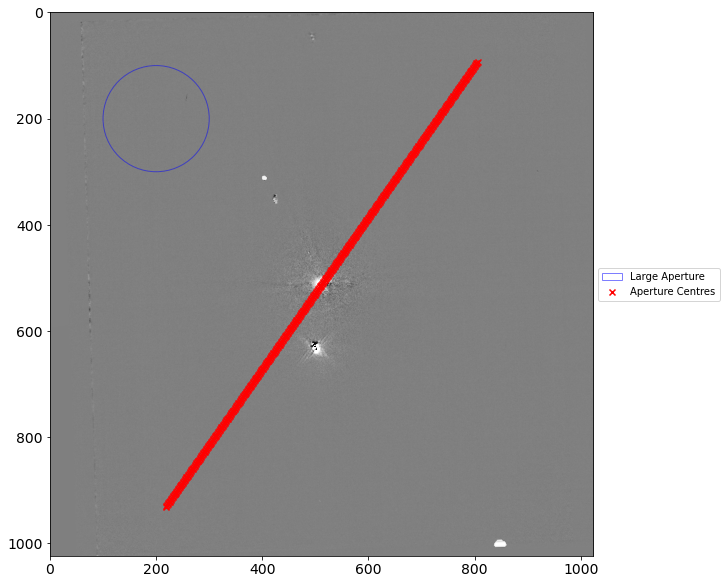

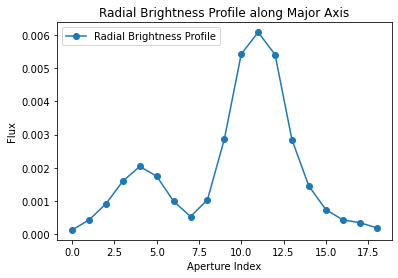

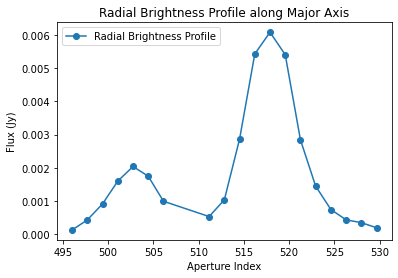

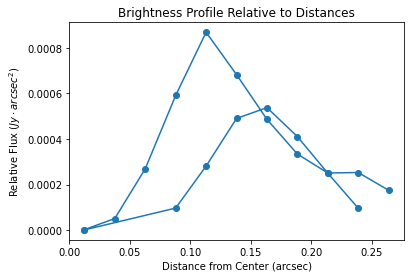

Jmag    0.000142
Name: 0, dtype: float32


In [73]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd144432.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd144432.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd144432.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD144432'
file_path = 'HD_144432_SPHERE_2016-05-26_J.fits'
angle_major_axis = 125  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0003429140685783621


<ipython-input-74-3be3123ebe07>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


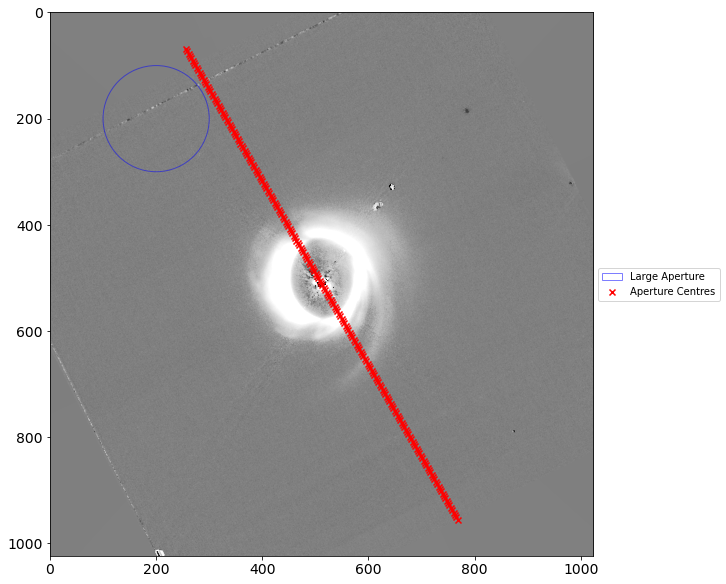

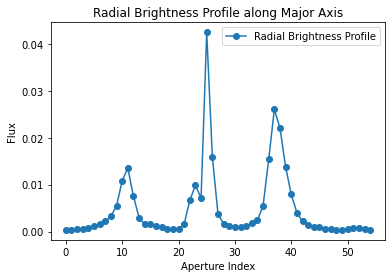

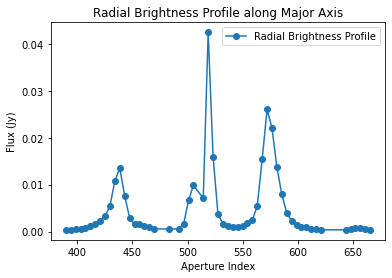

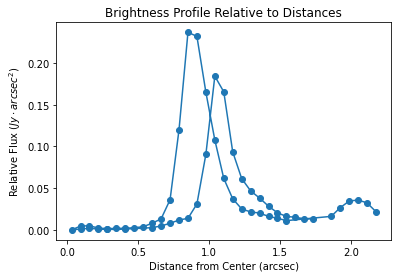

Hmag    0.007495
Name: 0, dtype: float32


In [74]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd142527.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd142527.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd142527.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD142527'
file_path = 'HD_142527_SPHERE_2017-06-01_H.fits'
angle_major_axis = 60  # angle of the major axis
num_apertures = 200
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00018837482647391464


<ipython-input-75-de6f69e64f60>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


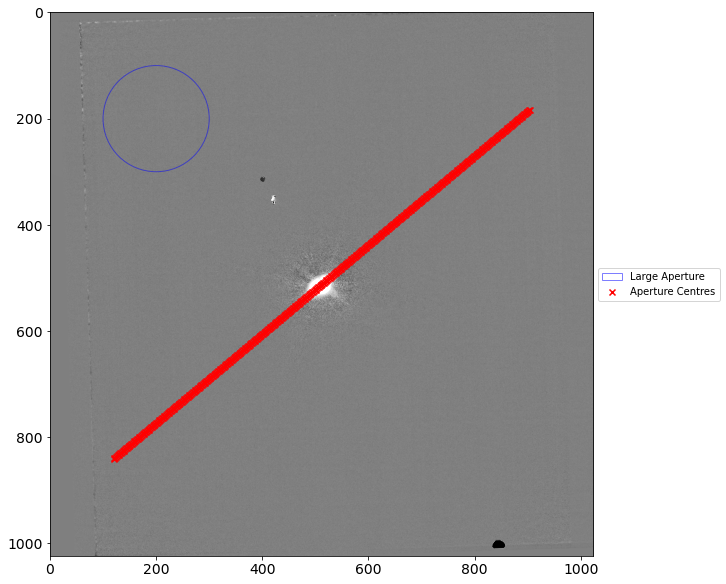

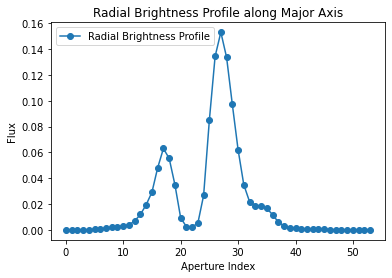

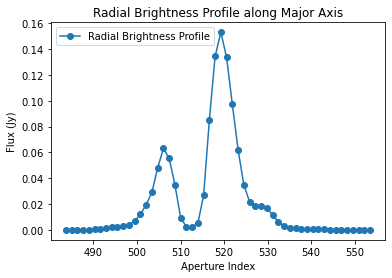

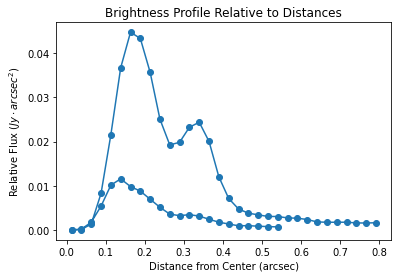

Jmag    0.008134
Name: 0, dtype: float32


In [75]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_CQ_tau.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_CQ_Tau.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_CQ_Tau.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'CQ Tau'
file_path = 'CQTau_SPHERE_2017-10-06_J.fits'
angle_major_axis = 140  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00011554808481262062


<ipython-input-76-3c27ba59b2f7>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


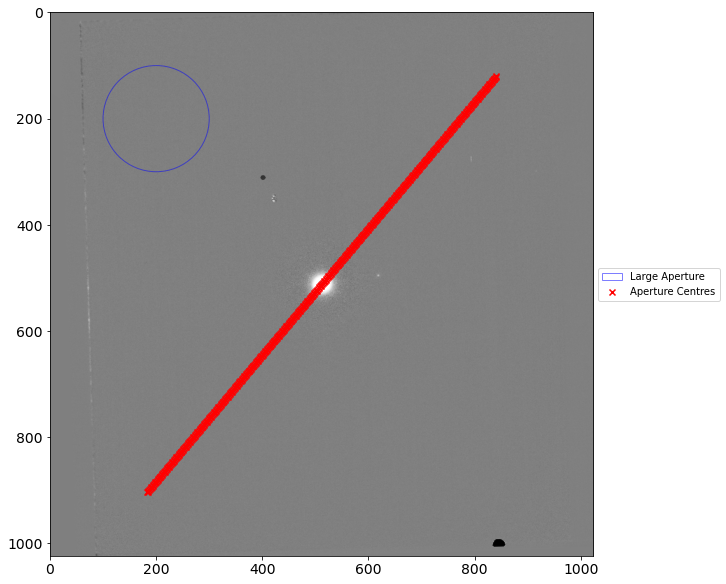

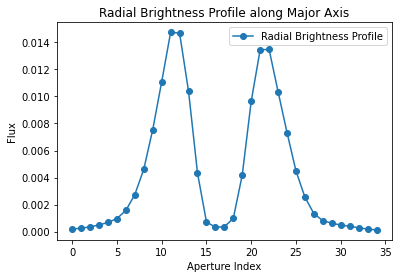

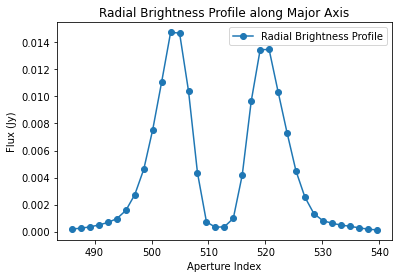

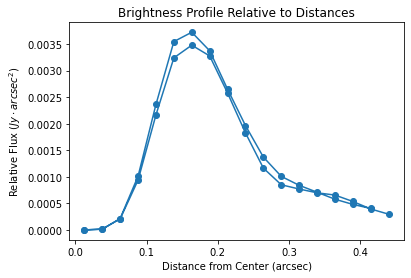

Jmag    0.003797
Name: 0, dtype: float32


In [76]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_CS_Cha.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_CS_Cha.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_CS_Cha.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'CS Cha'
file_path = 'CSCha_SPHERE_2017-02-17_J.fits'
angle_major_axis = 130  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00020988252654388471


<ipython-input-78-43e43f720559>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


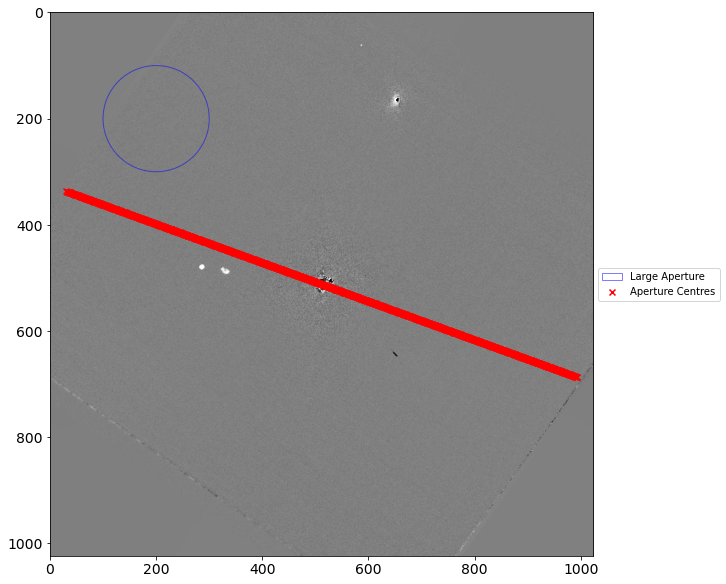

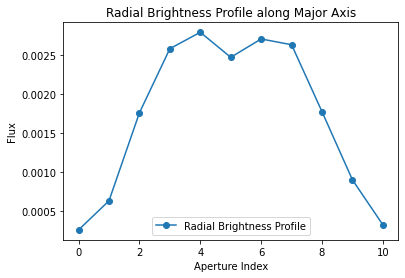

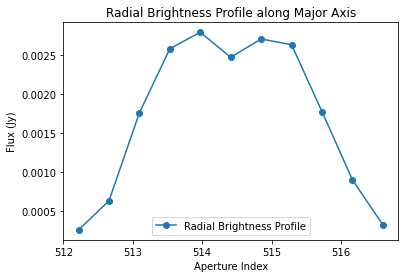

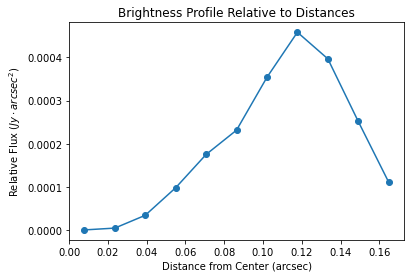

Hmag    0.000112
Name: 0, dtype: float32


In [78]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_DI_CHa.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_DI_Cha.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_DI_Cha.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'DI Cha'
file_path = 'DI_Cha_SPHERE_2017-03-21_H.fits'
angle_major_axis = 20  # angle of the major axis
num_apertures = 800
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00020535033693590662


<ipython-input-79-7889f205f75b>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


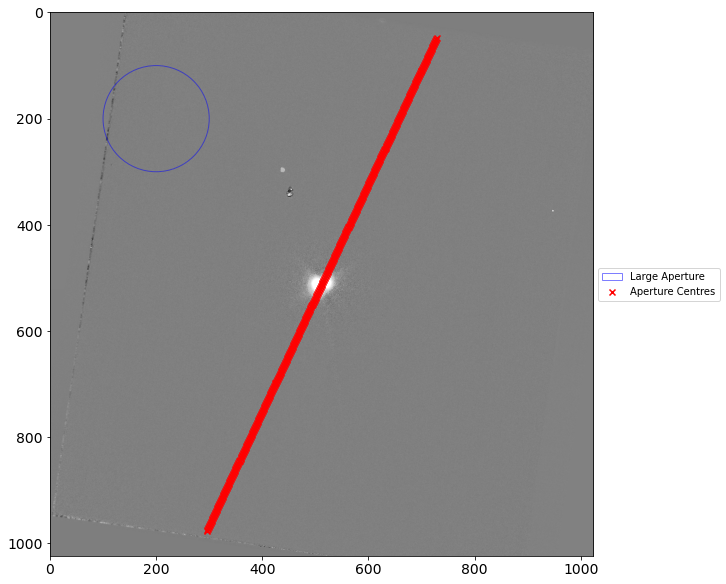

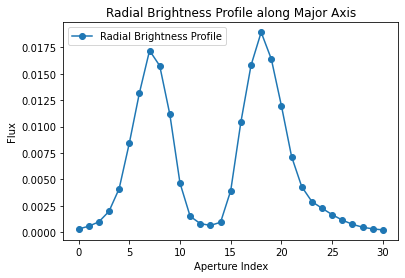

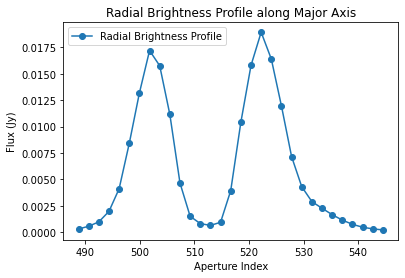

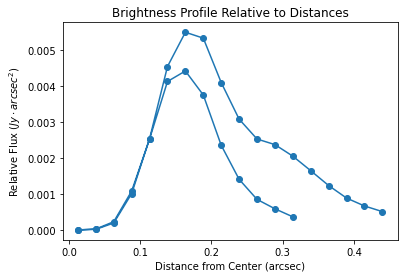

Hmag    0.00376
Name: 0, dtype: float32


In [79]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_DoAr_44.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_DoAr_44.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_DoAr_44.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'DoAr 44'
file_path = 'DoAr_44_SPHERE_2016-03-16_H.fits'
angle_major_axis = 115  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

8.506792775908584e-05


<ipython-input-80-a90cbddca3fd>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


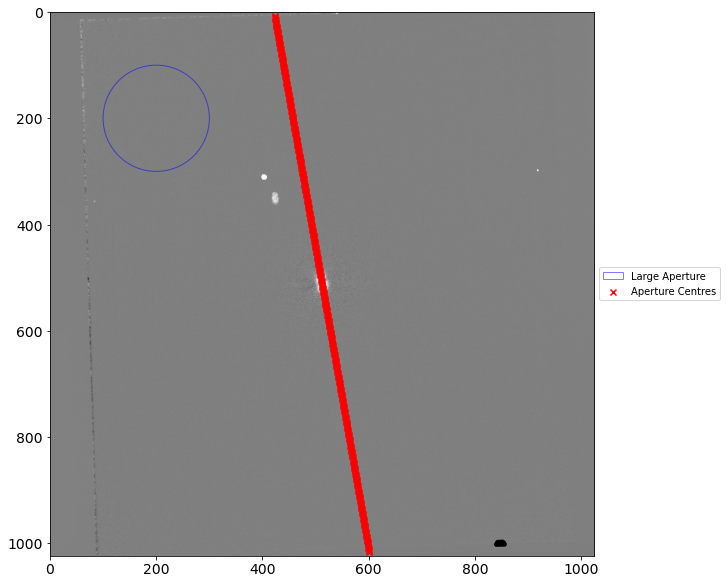

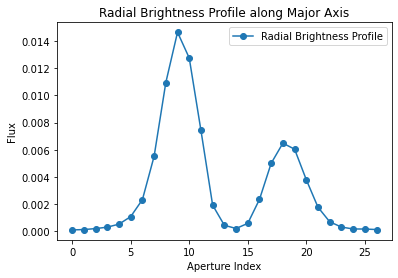

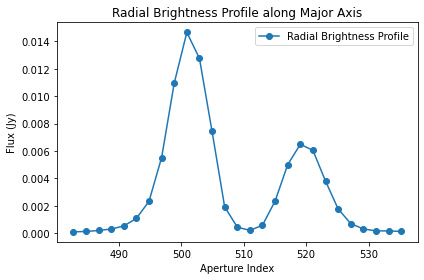

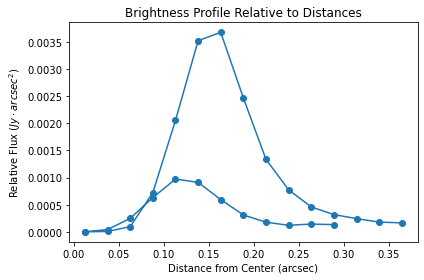

Jmag    0.002898
Name: 0, dtype: float32


In [80]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.savefig('image_DZ_Cha.jpg')
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        if dist_arcsec > 5:
            continue
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.tight_layout()
    plt.savefig('rel_brightness_DZ_Cha.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        if y < 100:
            continue
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.tight_layout()
    plt.savefig('brightness_profile_DZ_Cha.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'DZ Cha'
file_path = 'DZ_cha_SPHERE_2016-04-15_J.fits'
angle_major_axis = 80  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00022963878948499983


<ipython-input-81-08d878d7c2cd>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


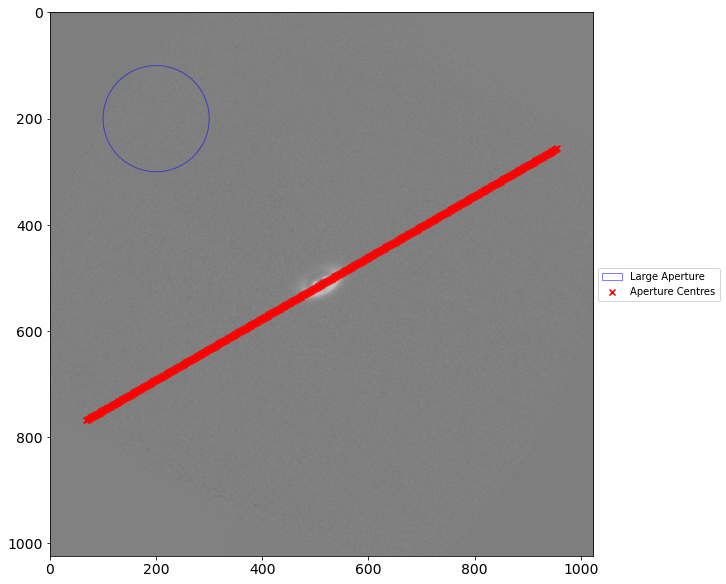

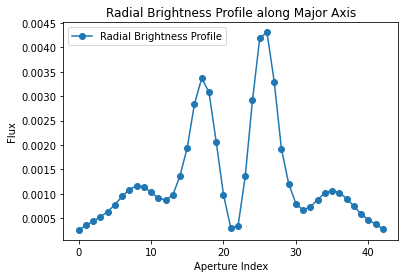

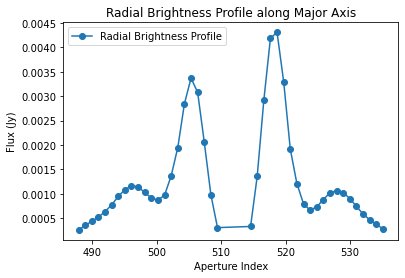

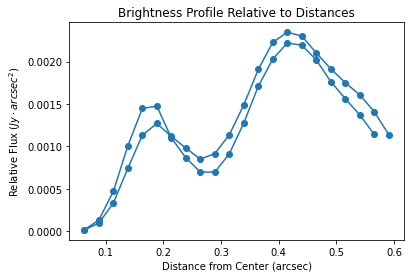

Kmag    0.003535
Name: 0, dtype: float32


In [81]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_LkCa15.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_LkCa15.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_LkCa15.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'LkCa15'
file_path = 'EM_LkCa___15_SPHERE_2020-12-08_K.fits'
angle_major_axis = 150  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0005302297598464107


<ipython-input-25-2039a9825f64>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


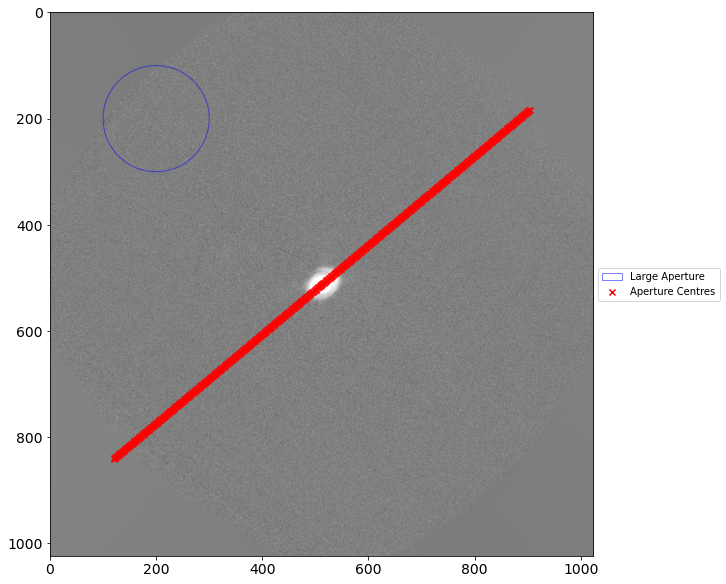

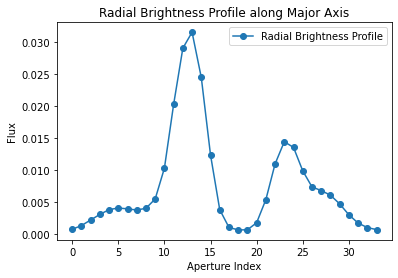

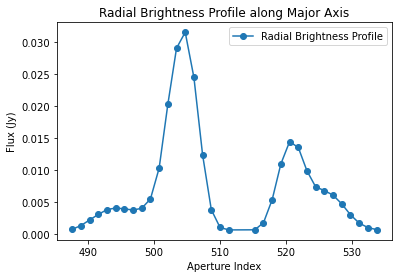

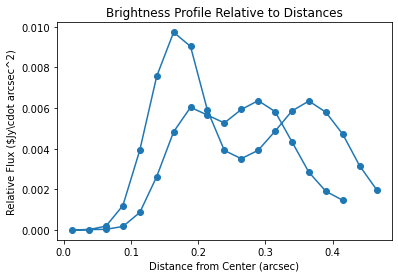

Kmag    0.003895
Name: 0, dtype: float32


In [25]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_LkHa330.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_LkHa330.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_LkHa330.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'LkHa 330'
file_path = 'EM_LkHA__330_SPHERE_2020-12-08_K.fits'
angle_major_axis = 140  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00022043800941034386


<ipython-input-26-3944ef8775f8>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


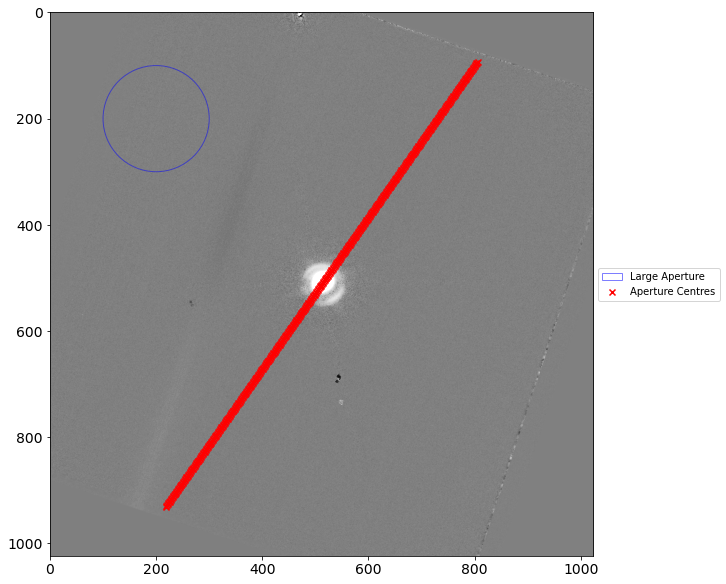

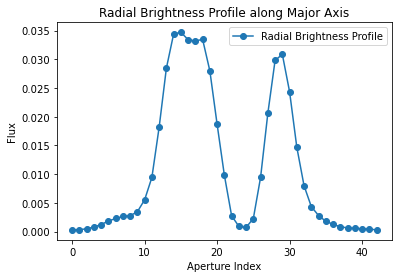

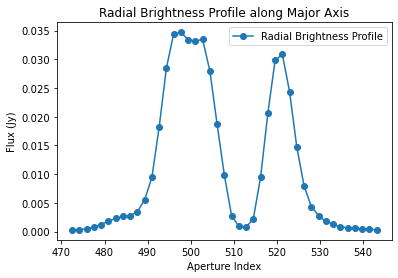

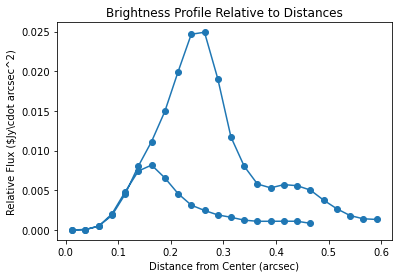

Hmag    0.00542
Name: 0, dtype: float32


In [26]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_EMSR21.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_EMSR21.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_EMSR21.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'EM* SR21'
file_path = 'EM_SR21_SPHERE_2018-03-01_H.fits'
angle_major_axis = 125  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00017562536512031788


<ipython-input-27-390816267b82>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


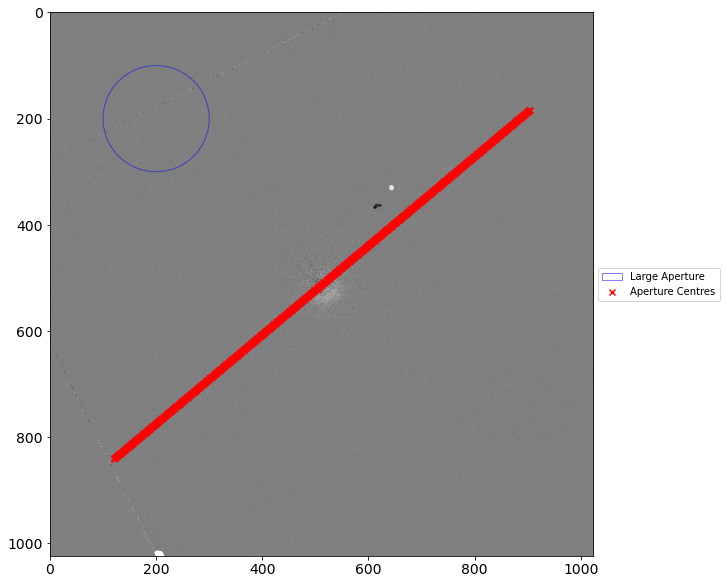

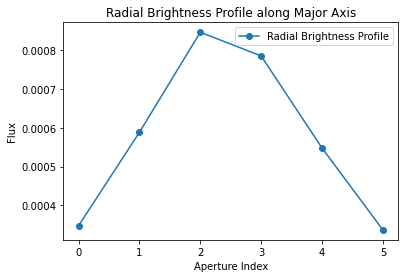

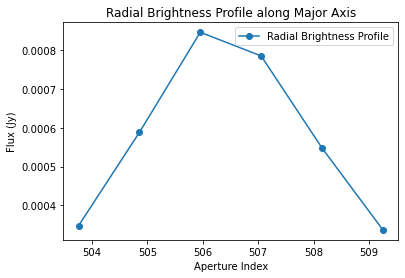

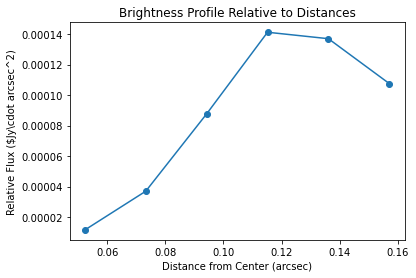

Hmag    0.000325
Name: 0, dtype: float32


In [27]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_EX_Lup.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_EX_Lup.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3*aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_EX_Lup.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'EX Lup'
file_path = 'EX_Lup_SPHERE_2017-05-16_H.fits'
angle_major_axis = 140  # angle of the major axis
num_apertures = 600
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00026946330957745536


<ipython-input-28-16729bdd72e7>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


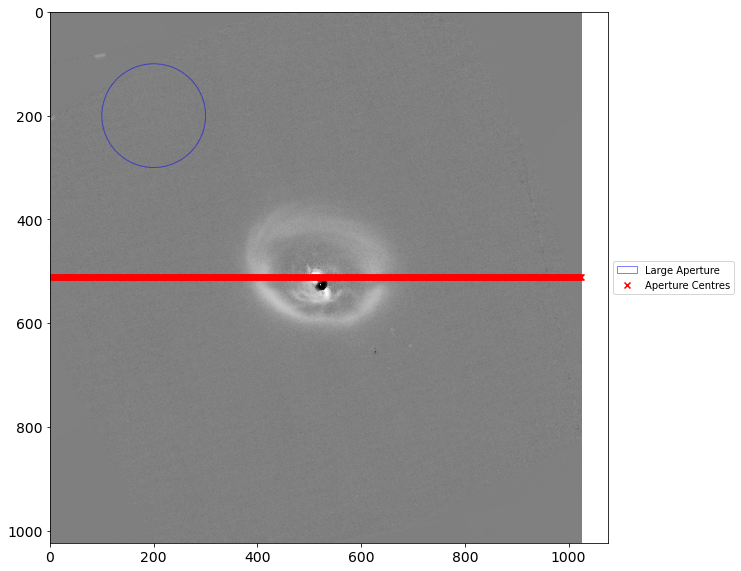

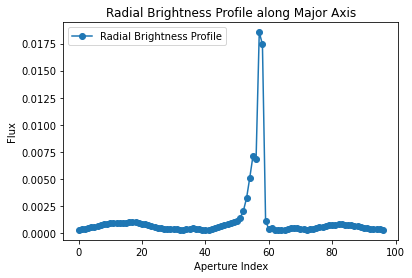

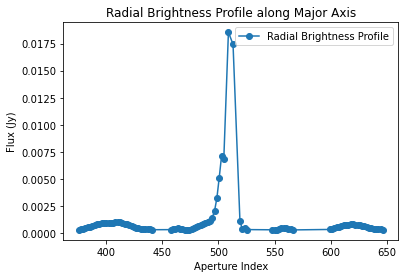

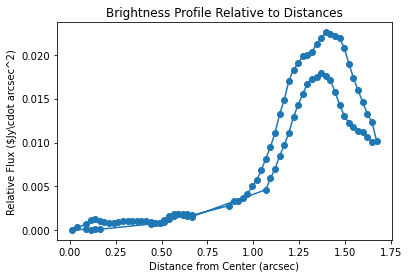

Hmag    0.010872
Name: 0, dtype: float32


In [28]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_GG_tau.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_GG_Tau.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3*aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(x)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_GG_Tau.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'GG Tau'
file_path = 'GGTauA_SPHERE_2016-11-19_H.fits'
angle_major_axis = 0  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00024571253100443203


<ipython-input-32-00918e6c326b>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


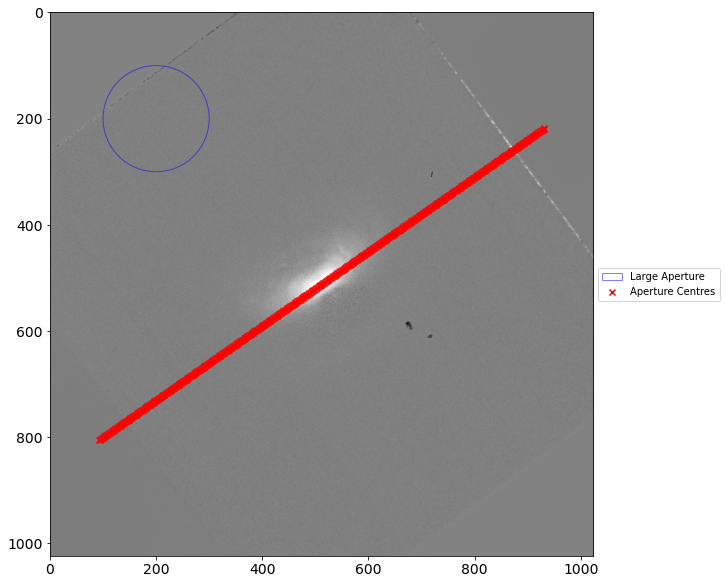

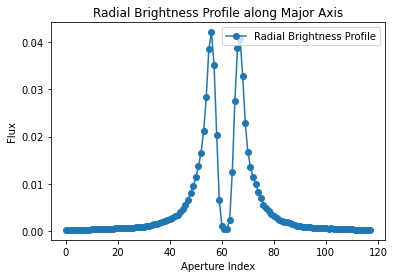

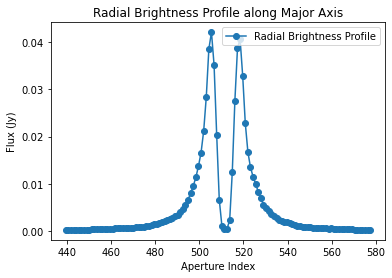

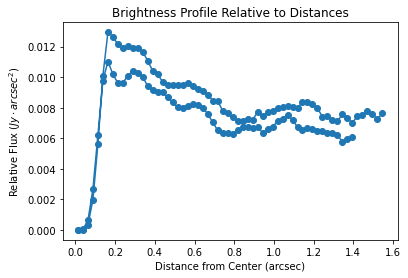

Hmag    0.020804
Name: 0, dtype: float32


In [32]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_GM_Aur.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        if distance_pixel > 300:
            continue
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_GM_Aur.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        if y < 280:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_GM_Aur.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'GM Aur'
file_path = 'GM_Aur_SPHERE_2018-01-02_H_RvH.fits'
angle_major_axis = 145  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0002164874608486453


<ipython-input-36-a514c9c0aa9c>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


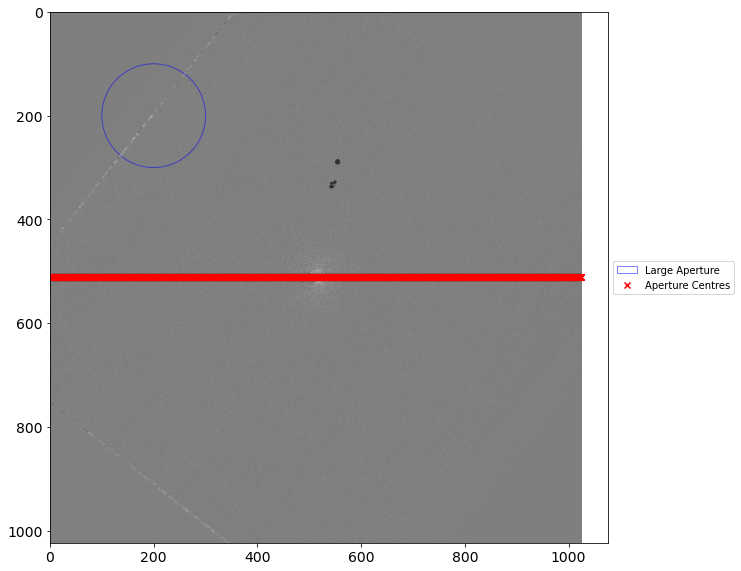

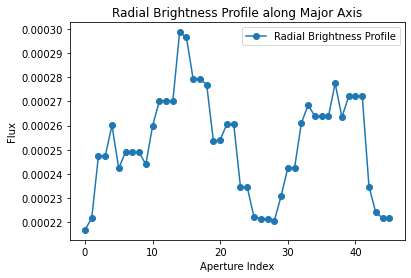

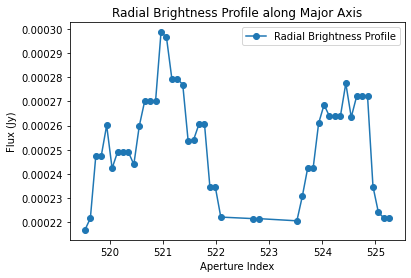

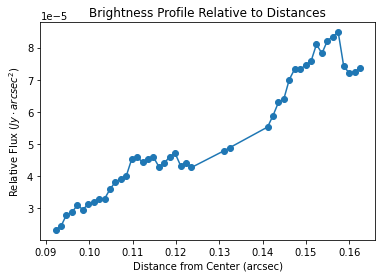

Hmag    0.000239
Name: 0, dtype: float32


In [36]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_GW_Lup.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_GW_Lup.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(x)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_GW_Lup.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'GW Lup'
file_path = 'GW_Lup_SPHERE_2018-03-01_H.fits'
angle_major_axis = 0  # angle of the major axis
num_apertures = 10000
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.000295242041416777


<ipython-input-37-c62a069a92c5>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


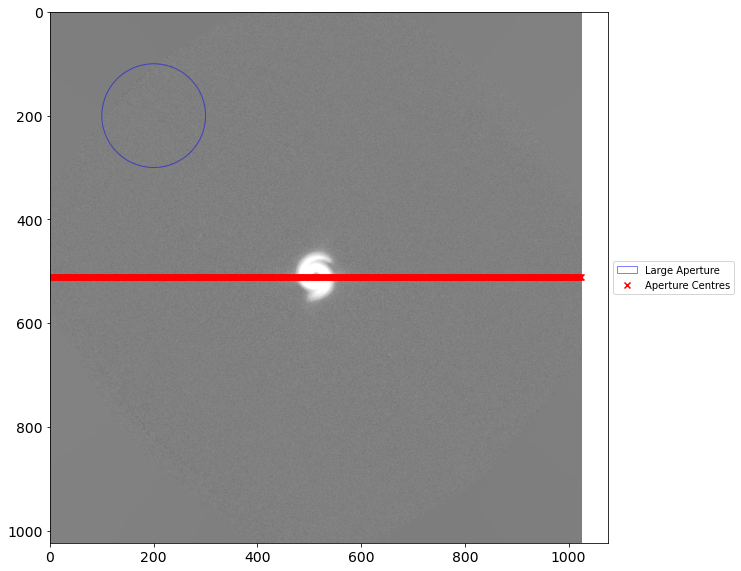

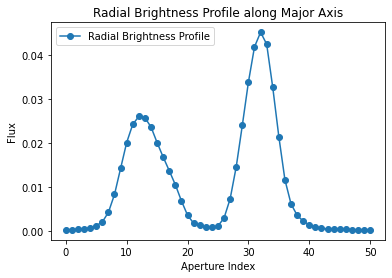

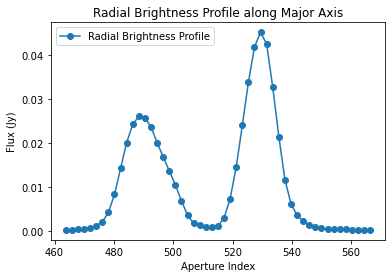

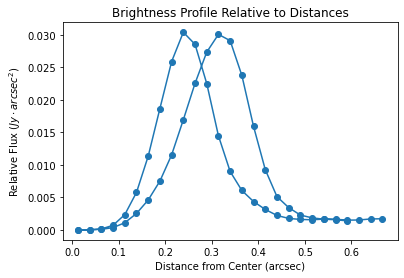

Kmag    0.002601
Name: 0, dtype: float32


In [37]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd36112.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd36112.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(x)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd36112.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD36112'
file_path = 'HD__36112_SPHERE_2020-12-26_K.fits'
angle_major_axis = 0  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00017727498922066664


<ipython-input-38-658693300ac3>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


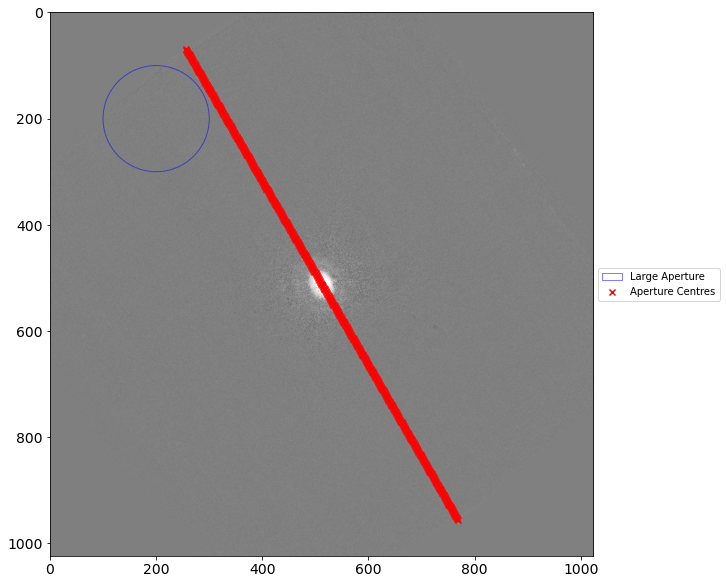

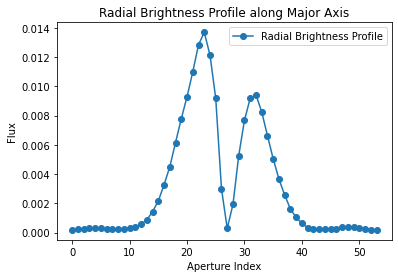

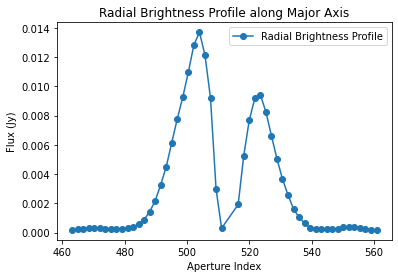

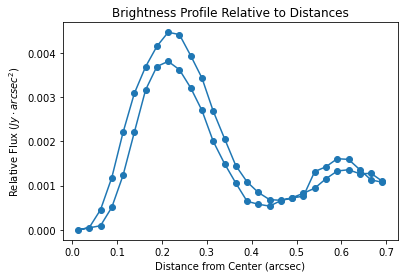

Hmag    0.000536
Name: 0, dtype: float32


In [38]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd31648.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd31648.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd31648.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD31648'
file_path = 'HD_31648_SPHERE_2018-11-27_H_RvH.fits'
angle_major_axis = 60  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

<ipython-input-39-c2a0d85eb823>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


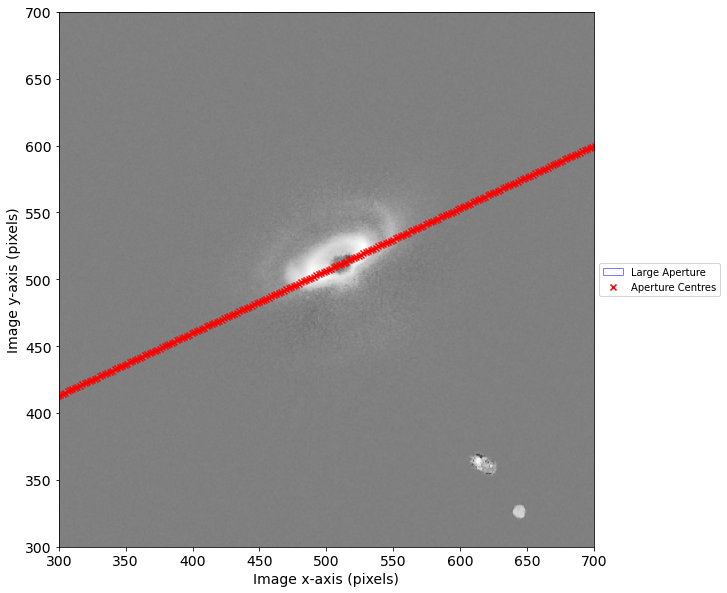

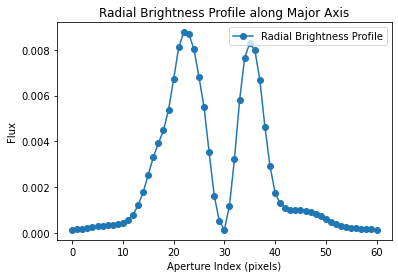

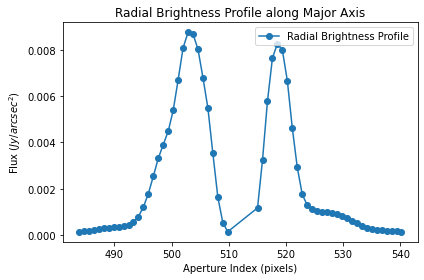

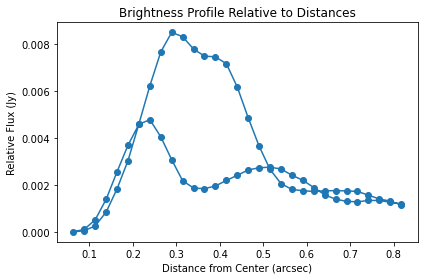

Jmag    0.009193
Name: 0, dtype: float32


In [39]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    plt.gca().invert_yaxis()
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.xlabel('Image x-axis (pixels)', fontsize=14)
    plt.ylabel('Image y-axis (pixels)', fontsize=14)
    plt.xlim(300, 700)
    plt.ylim(300, 700)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.savefig('image_hd34282.jpg')
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the noise
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux (Jy)')
    plt.title('Brightness Profile Relative to Distances')
    plt.tight_layout()
    plt.savefig('rel_brightness_hd34282.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        brightness_profile.append(flux)
        aperture_values.append(y)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index (pixels)')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index (pixels)')
    plt.ylabel('Flux ($Jy/arcsec^2$)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.tight_layout()
    plt.savefig('brightness_profile_hd34282.jpg')
    plt.show()
    
    # Function 5: Plot the flux of the disk relative to the distance of the apertures
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    #Function 6: Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD34282'
file_path = 'HD_34282_SPHERE_2015-12-19_J.fits'
angle_major_axis = 25  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0006160056999174606


<ipython-input-40-e10f6a2e2807>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


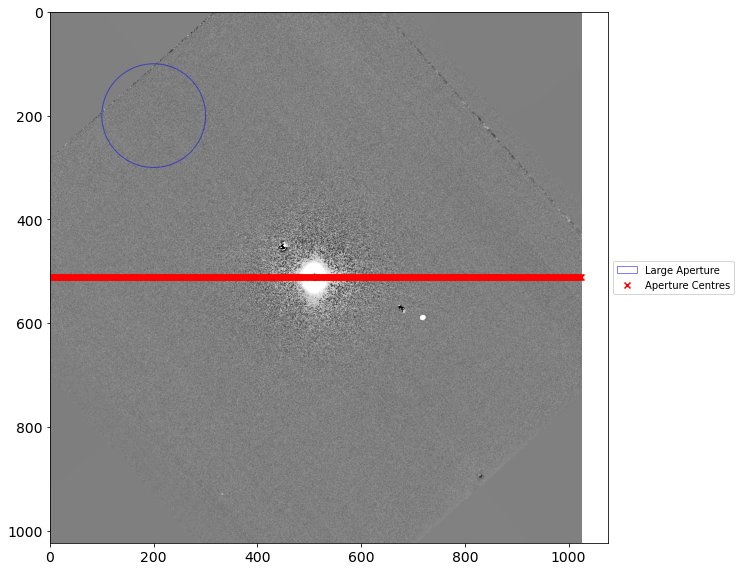

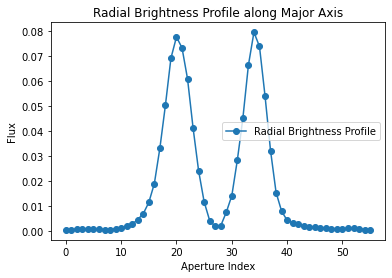

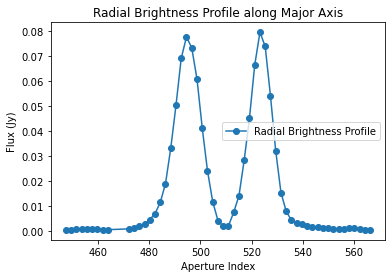

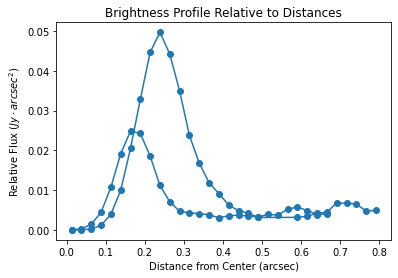

Hmag    0.003476
Name: 0, dtype: float32


In [40]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd100453.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd100453.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(x)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd100453.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD100453'
file_path = 'HD_100453_SPHERE_2018-06-06_H.fits'
angle_major_axis = 0  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0006704639110584061


<ipython-input-41-11e599df579d>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


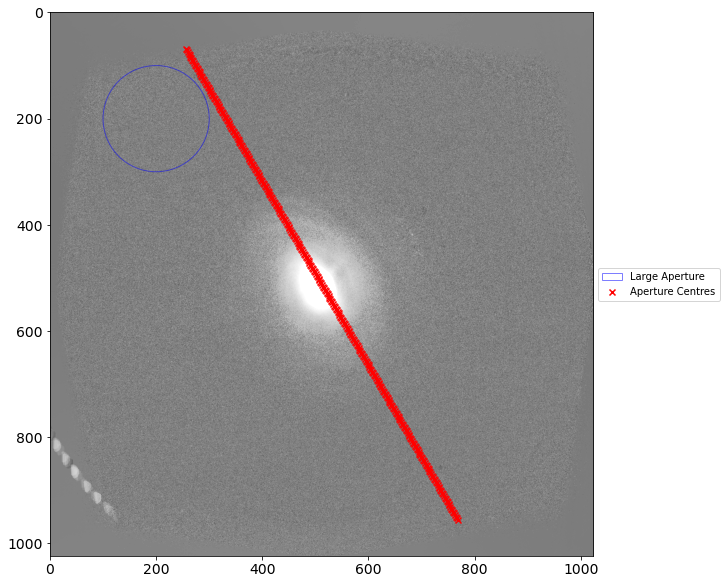

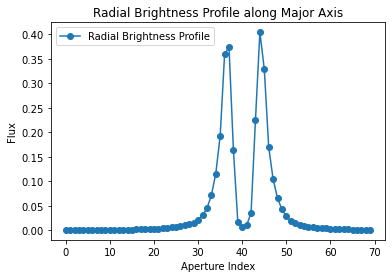

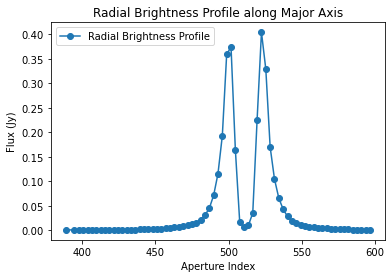

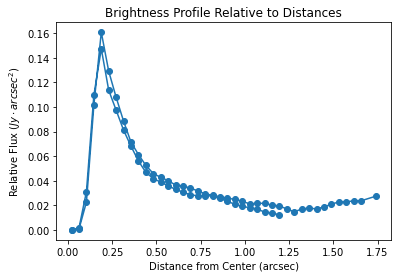

Kmag    0.008777
Name: 0, dtype: float32


In [41]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd100546.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd100546.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd100546.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD100546'
file_path = 'HD_100546_SPHERE_2020-12-22_K.fits'
angle_major_axis = 60  # angle of the major axis
num_apertures = 300
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00044608526651491743


<ipython-input-42-b5eeba8230aa>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


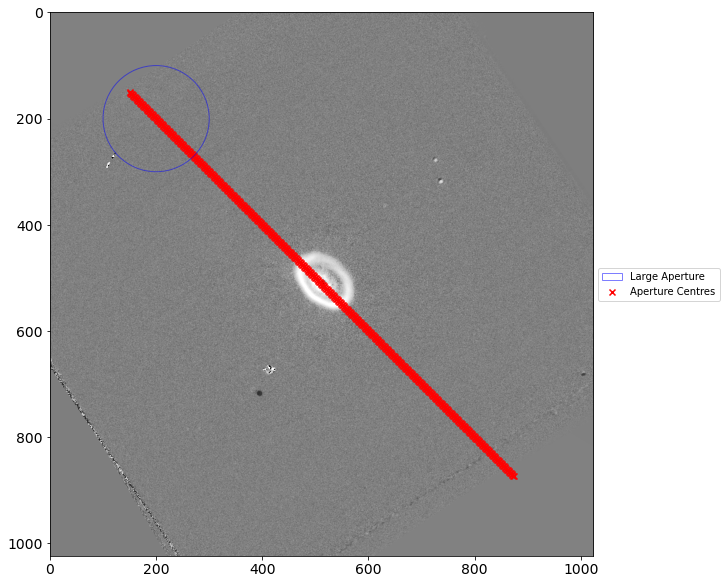

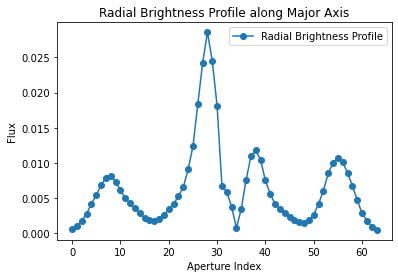

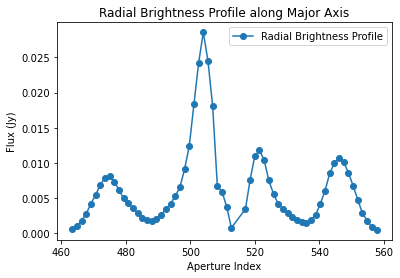

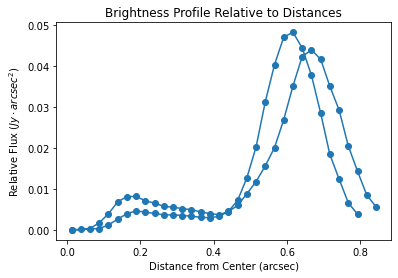

Kmag    0.001636
Name: 0, dtype: float32


In [42]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd163296.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd163296.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd163296.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD163296'
file_path = 'HD_163296_SPHERE_2022-07-07_K.fits'
angle_major_axis = 45  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0005454675371428133


<ipython-input-43-58ff49ae90c8>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


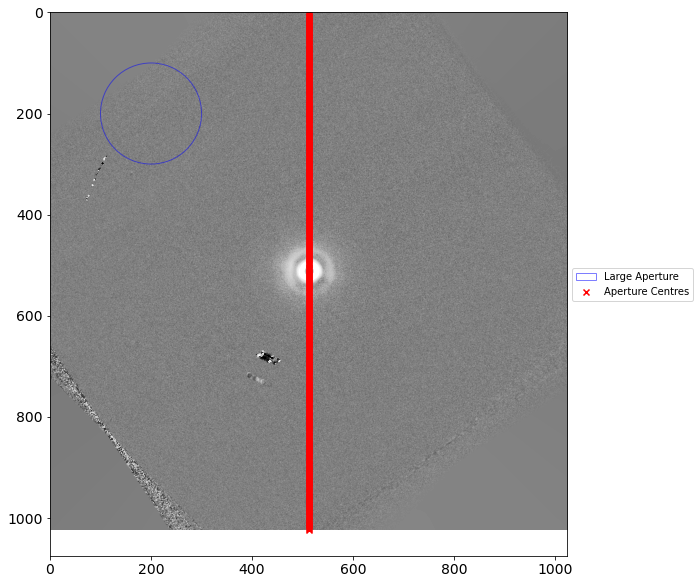

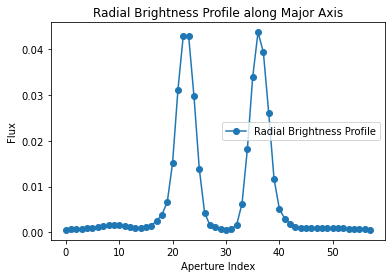

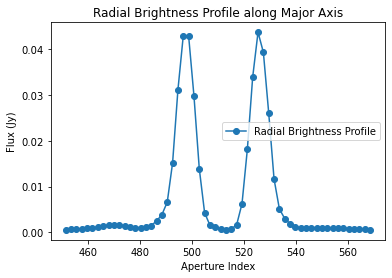

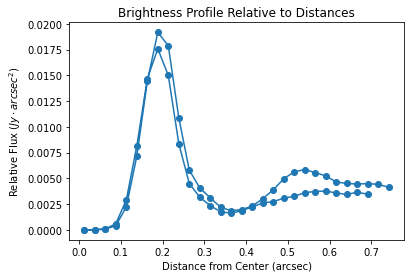

Kmag    0.002626
Name: 0, dtype: float32


In [43]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd169142.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd169142.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd169142.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD169142'
file_path = 'HD_169142_SPHERE_2021-09-06_K.fits'
angle_major_axis = 90  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00016474119829910694


<ipython-input-44-269b75c64046>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


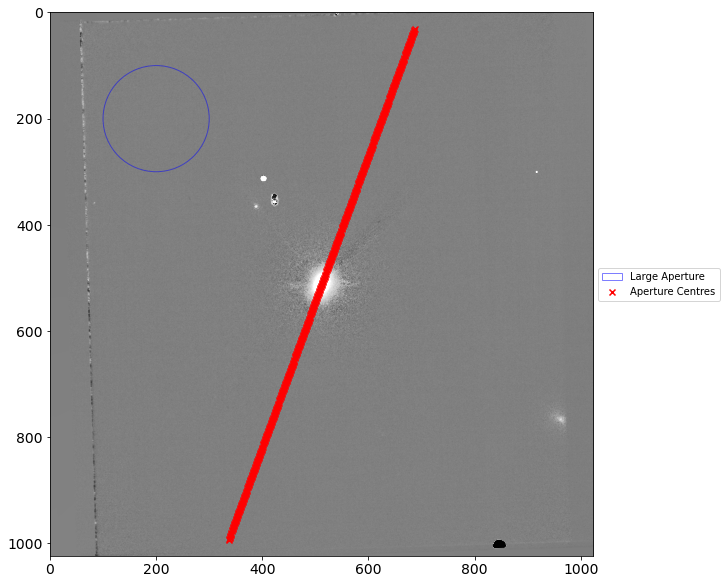

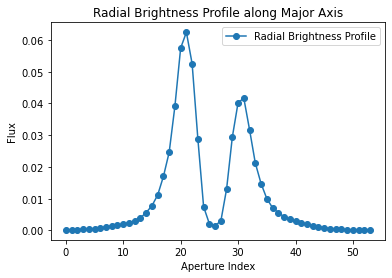

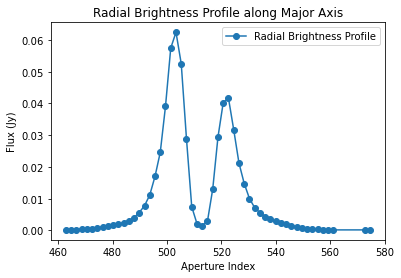

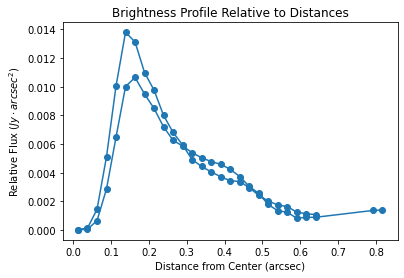

Jmag    0.001744
Name: 0, dtype: float32


In [44]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd179218.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd179218.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd179218.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD179218'
file_path = 'HD_179218_SPHERE_2016-05-26_J.fits'
angle_major_axis = 110  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0001286136352855021


<ipython-input-45-3a2923e9d3fa>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


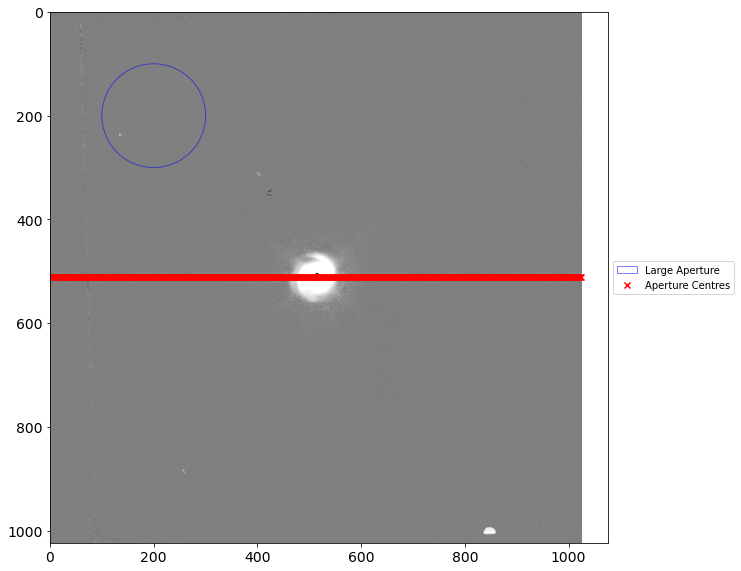

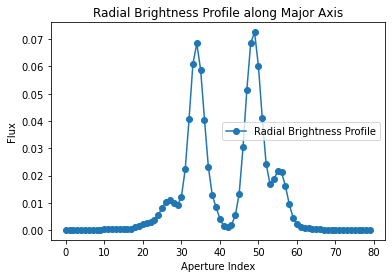

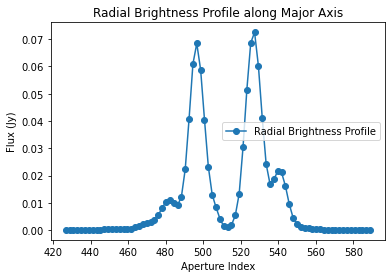

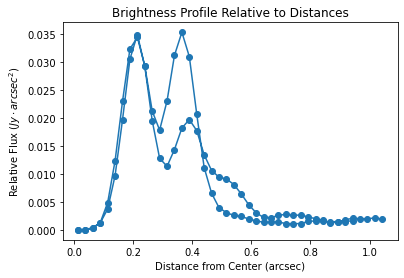

Jmag    0.004665
Name: 0, dtype: float32


In [45]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd135344b.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd135344b.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(x)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd135344b.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD135344B'
file_path = 'HD135344B_SPHERE_2015-05-03_J.fits'
angle_major_axis = 0  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00016407904900262756


<ipython-input-46-278180b589ce>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


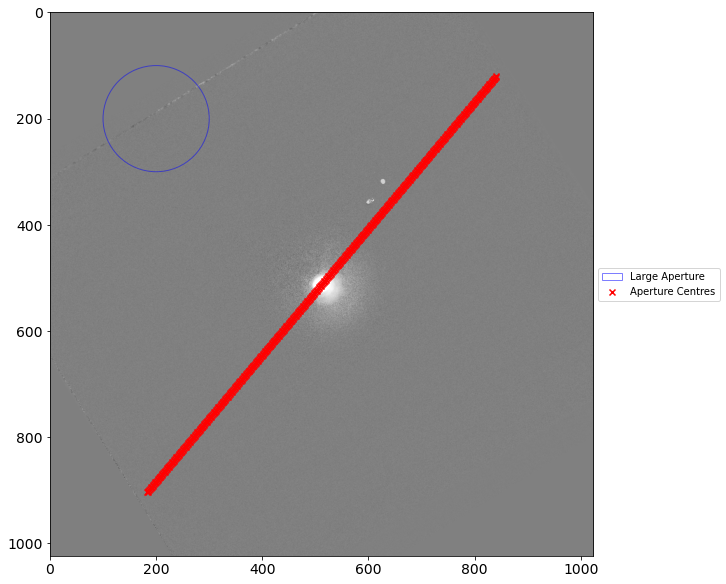

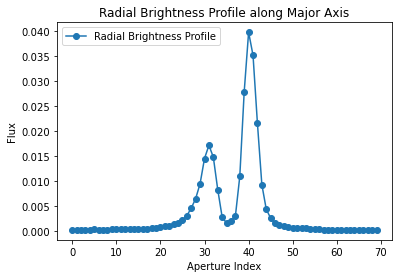

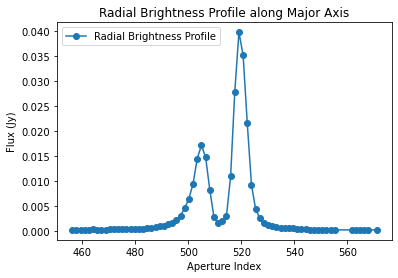

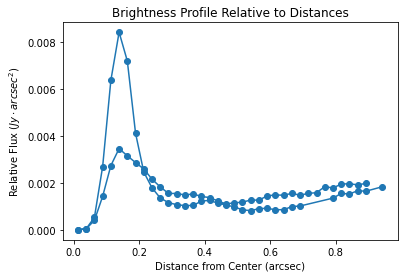

Hmag    0.001448
Name: 0, dtype: float32


In [46]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd139614.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd139614.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd139614.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD139614'
file_path = 'HD139614_SPHERE_2017-05-16_H.fits'
angle_major_axis = 130  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

7.502458146372196e-05


<ipython-input-47-fecc067d835e>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


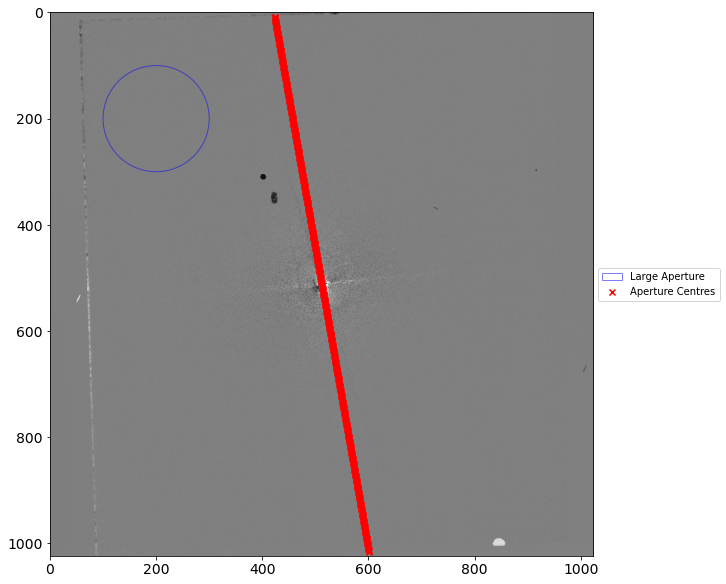

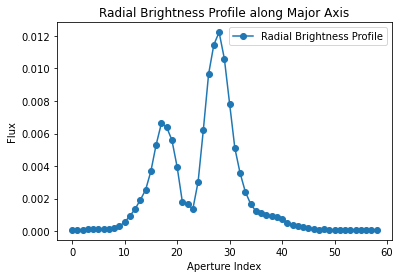

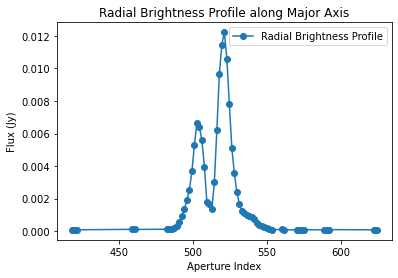

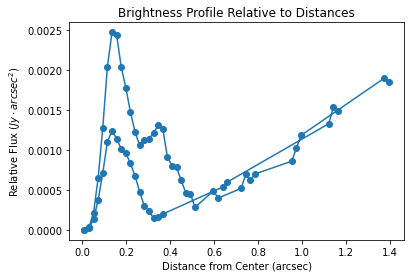

Jmag    0.000497
Name: 0, dtype: float32


In [47]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd142666.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        if distance_pixel > 450:
            continue
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd142666.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        if y > 800:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd142666.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD142666'
file_path = 'HD142666_SPHERE_2016-02-21_J.fits'
angle_major_axis = 80  # angle of the major axis
num_apertures = 600
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0002576158497025346


<ipython-input-48-d24abec6669b>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


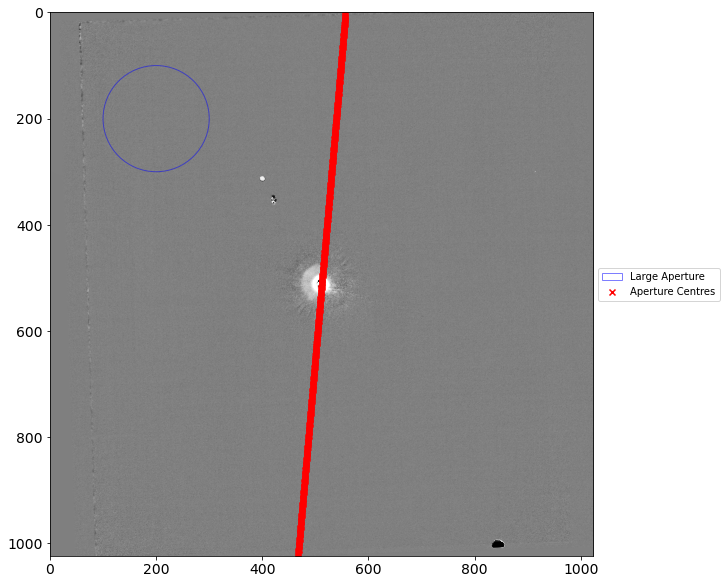

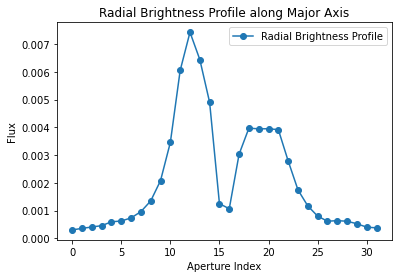

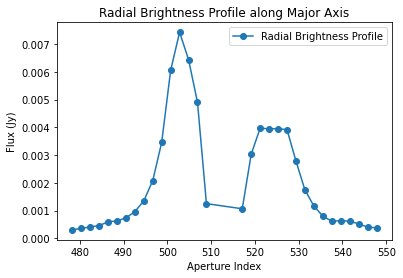

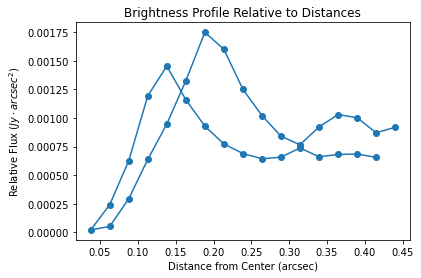

Jmag    0.001193
Name: 0, dtype: float32


In [48]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_hd143006.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_hd143006.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_hd143006.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'HD143006'
file_path = 'HD143006_SPHERE_2016-07-01_J.fits'
angle_major_axis = 95  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00010909179916843542


<ipython-input-49-2ff9d0fc8523>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


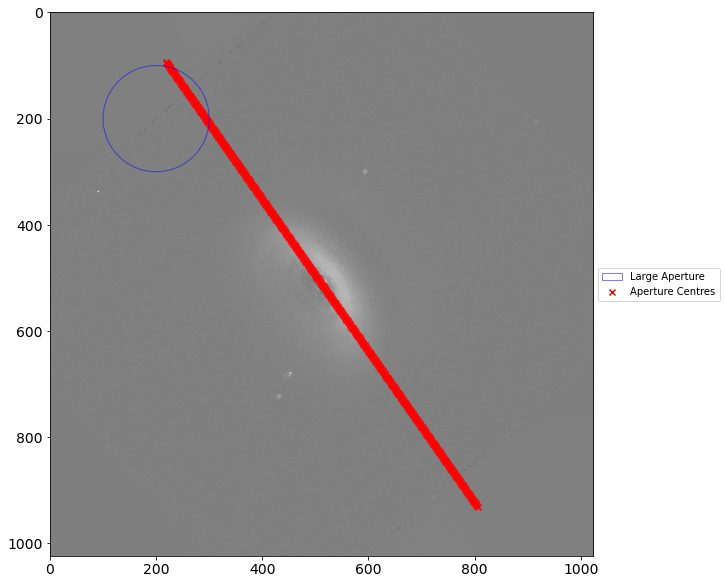

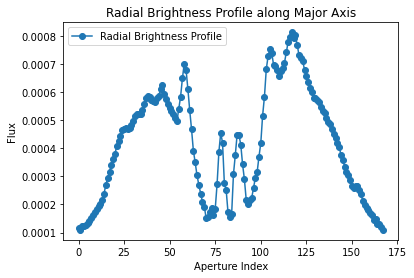

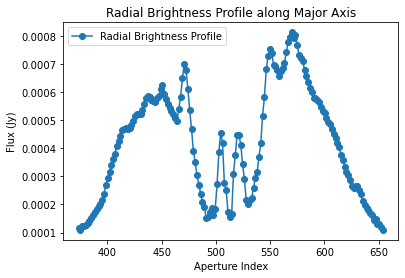

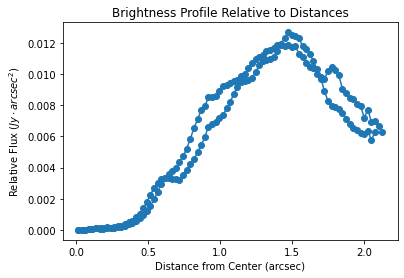

Hmag    0.010535
Name: 0, dtype: float32


In [49]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_IM_Lup.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_IM_Lup.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_IM_Lup.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'IM Lup'
file_path = 'IM_Lup_SPHERE_2016-03-14_H.fits'
angle_major_axis = 55  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00019165843094525866


<ipython-input-50-5039fcf8da1f>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


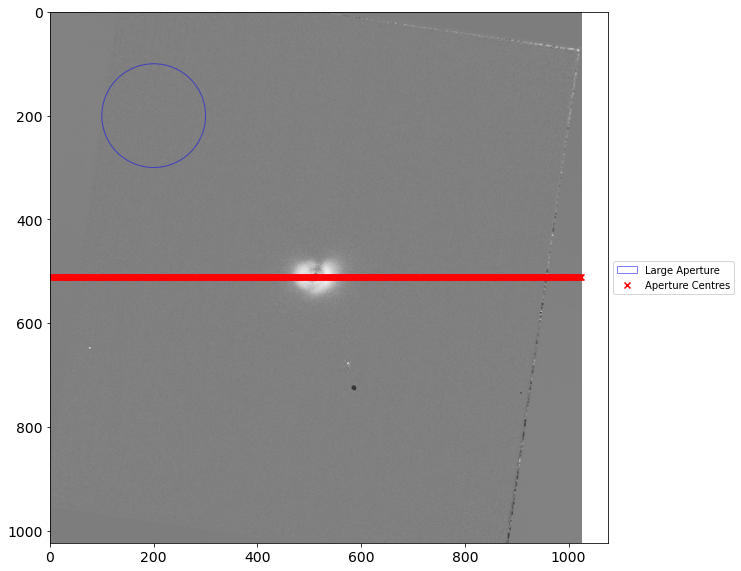

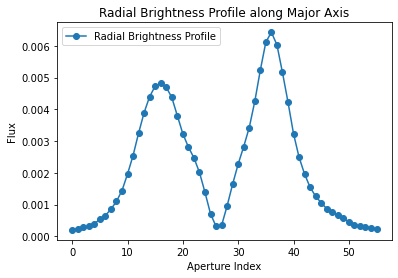

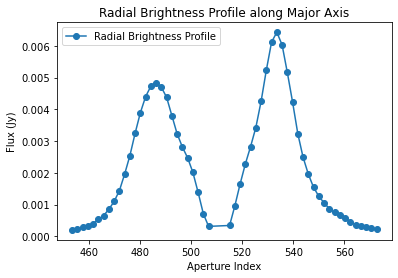

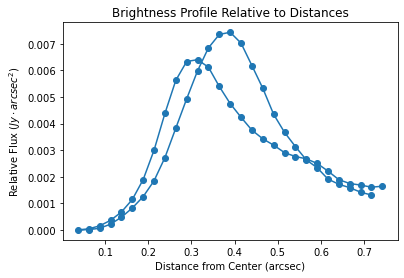

Hmag    0.022201
Name: 0, dtype: float32


In [50]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_IRAS08267.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_IRAS08267.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(x)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_IRAS08267.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'IRAS 08267-3336'
file_path = 'IRAS_08267-3336_SPHERE_2017-05-15_H.fits'
angle_major_axis = 0  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0003195795929041692


<ipython-input-51-c6f6d3a0e3b8>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


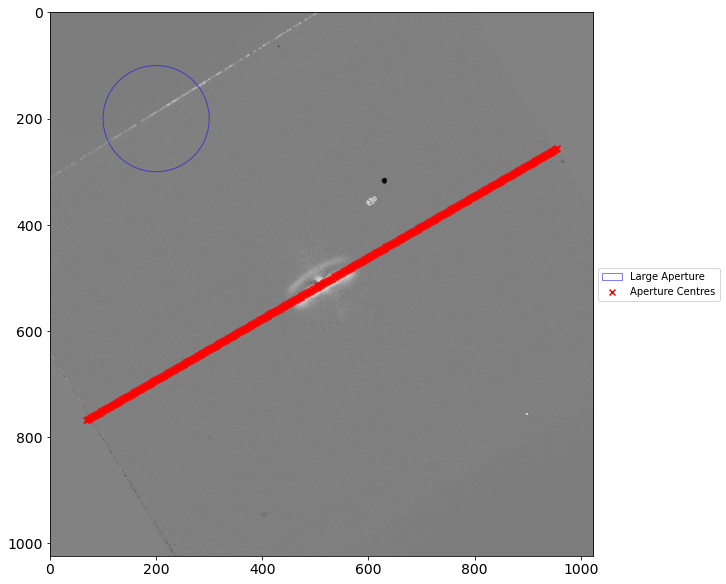

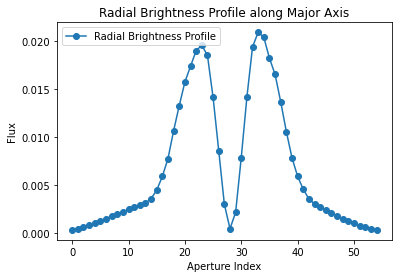

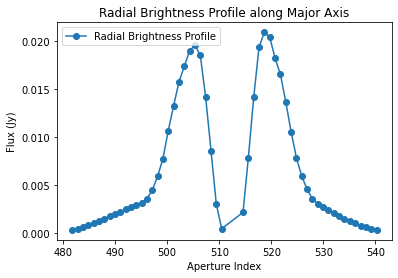

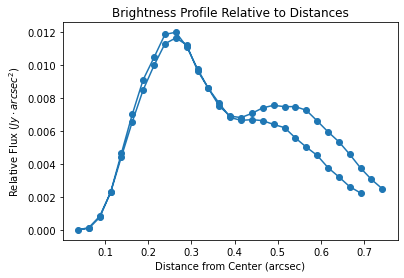

Hmag    0.018201
Name: 0, dtype: float32


In [51]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_MY_Lup.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_MY_Lup.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_MY_Lup.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'MY Lup'
file_path = 'MY_Lup_SPHERE_2016-03-16_H.fits'
angle_major_axis = 150  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.000127674641485361


<ipython-input-52-c7f8775c0965>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


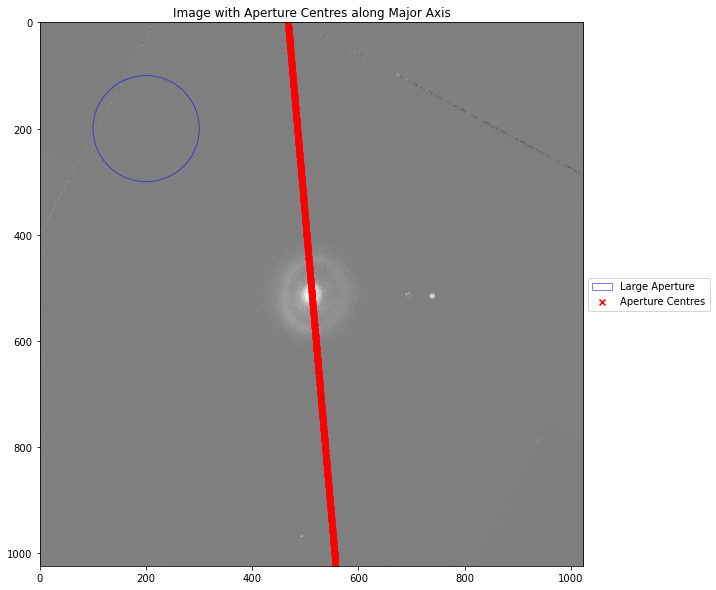

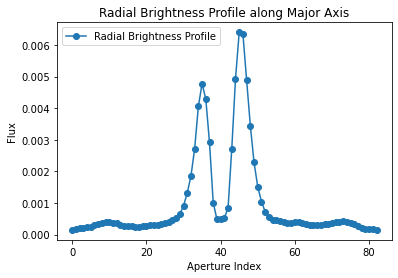

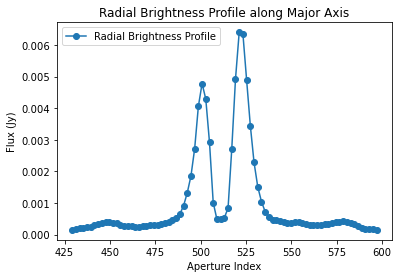

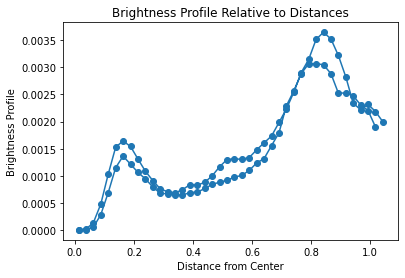

Hmag    0.001684
Name: 0, dtype: float32


In [52]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.title('Image with Aperture Centres along Major Axis')
    plt.savefig('image_PDS66.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center')
    plt.ylabel('Brightness Profile')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_PDS66.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_PDS66.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'PDS 66'
file_path = 'PDS_66_SPHERE_2016-03-16_H.fits'
angle_major_axis = 85  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0003167826082122401


<ipython-input-53-b0b713456d92>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


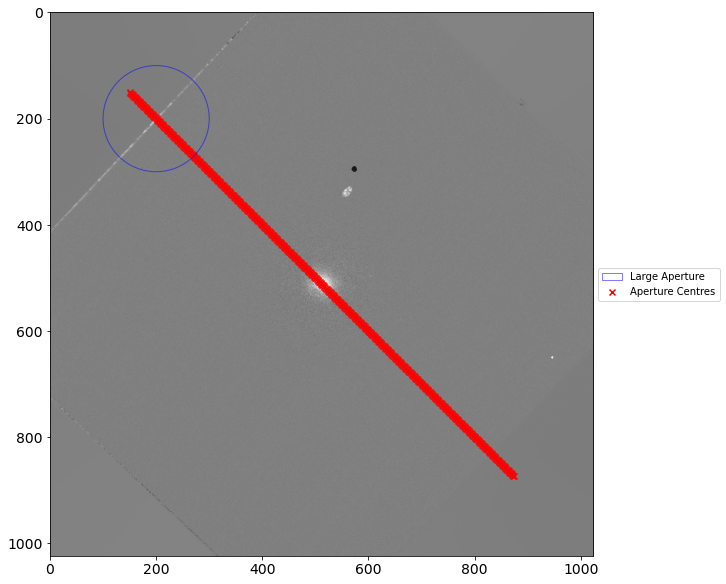

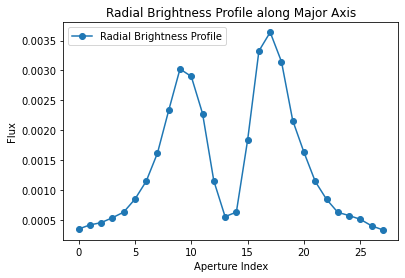

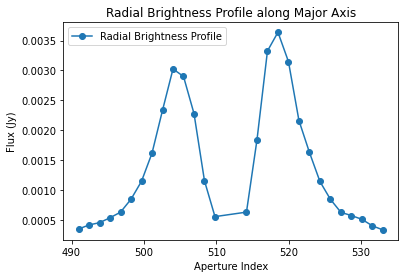

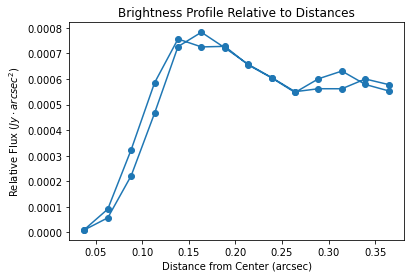

Hmag    0.000681
Name: 0, dtype: float32


In [53]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_RU_Lup.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_RU_Lup.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_RU_Lup.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'RU Lup'
file_path = 'RU_Lup_SPHERE_2016-03-13_H.fits'
angle_major_axis = 45  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

8.939077442577815e-05


<ipython-input-54-1ff37a40799e>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


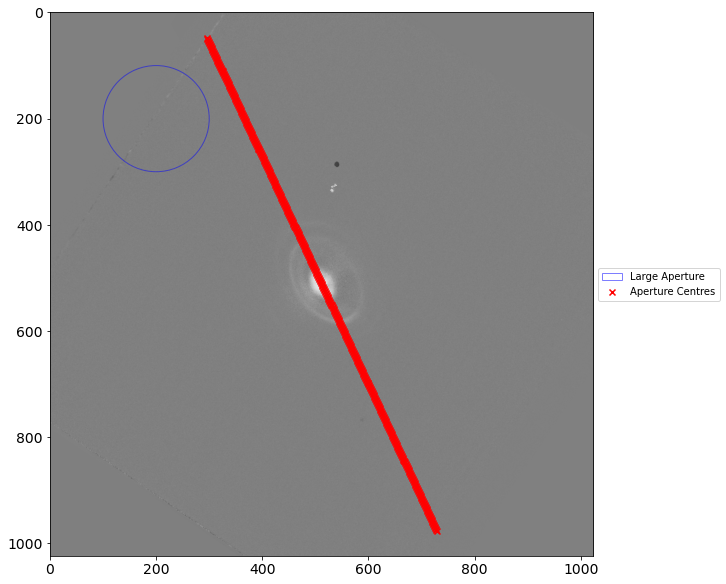

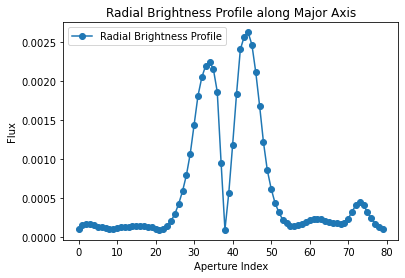

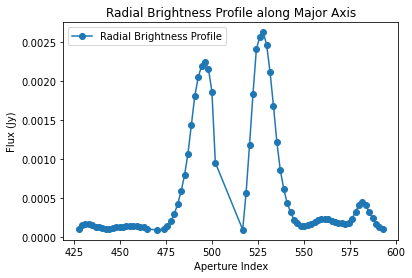

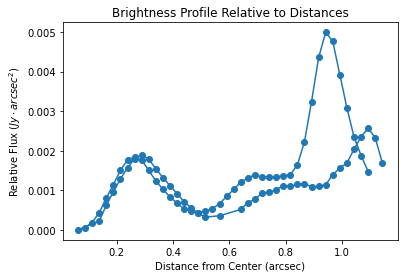

Hmag    0.004368
Name: 0, dtype: float32


In [54]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_RXJ1615.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_RXJ1615.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_RXJ1615.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'RX J1615.3-3255'
file_path = 'RXJ1615-3255_SPHERE_2016-03-15_H.fits'
angle_major_axis = 65  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00010927672098153955


<ipython-input-55-30b110adeb92>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


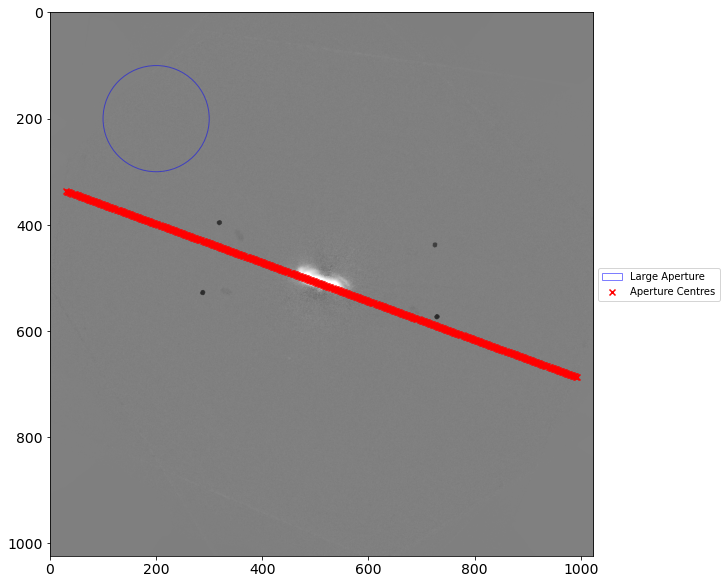

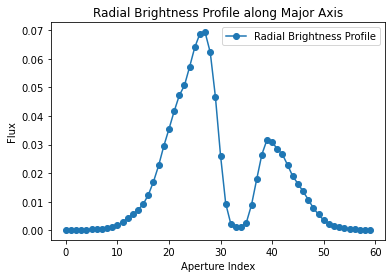

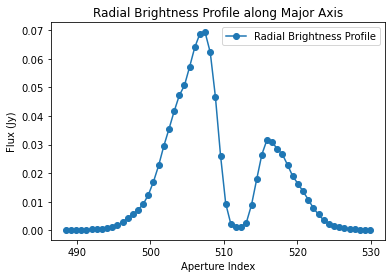

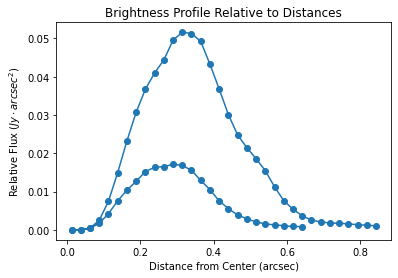

Hmag    0.015924
Name: 0, dtype: float32


In [55]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_RY_Lup.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_RY_Lup.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_RY_Lup.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'RY Lup'
file_path = 'RY_Lupi_SPHERE_2016-05-27_H.fits'
angle_major_axis = 20  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0002341752099595935


<ipython-input-56-005f37894214>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


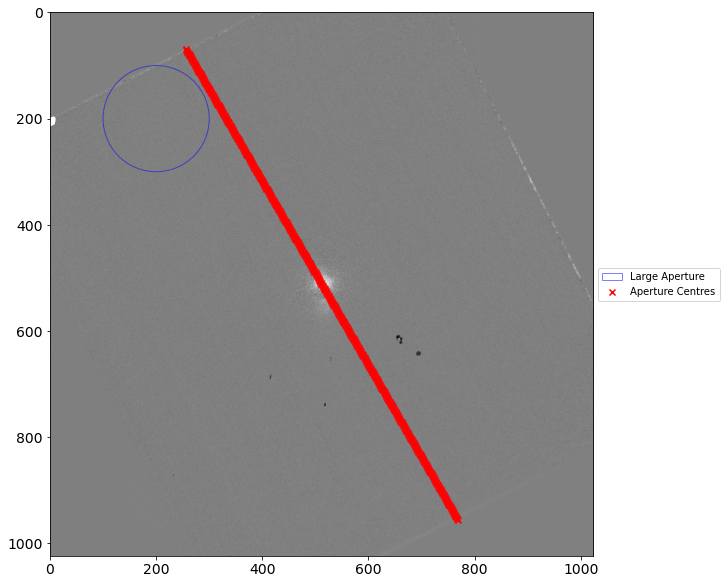

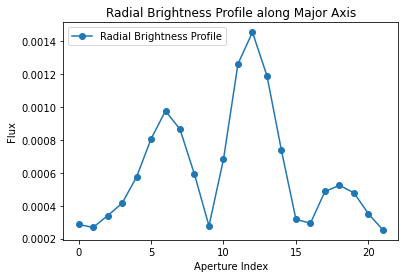

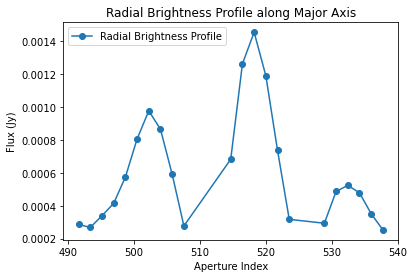

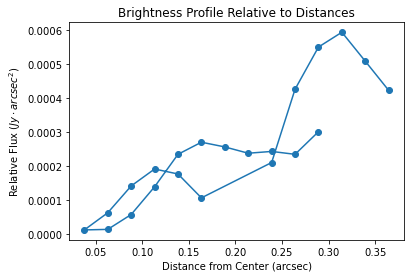

Hmag    0.001046
Name: 0, dtype: float32


In [56]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_SY_Cha.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        if dist_arcsec > 6:
            continue
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_SY_Cha.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        if y < 100:
            continue
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_SY_Cha.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'SY Cha'
file_path = 'SY_Cha_SPHERE_2017-05-16_H.fits'
angle_major_axis = 60  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00012840738197021065


<ipython-input-57-836276c40ad8>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


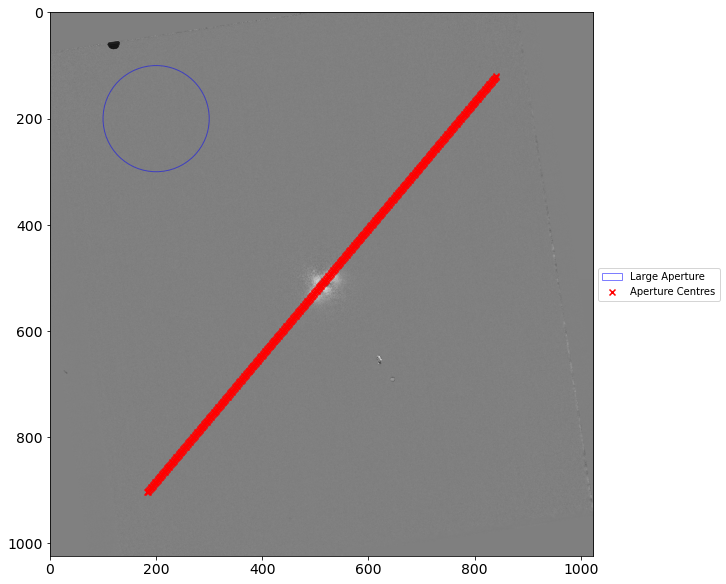

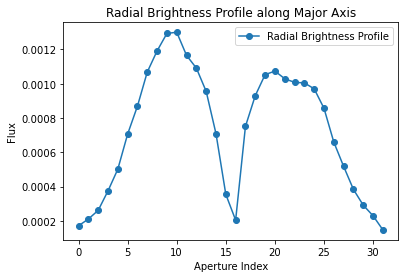

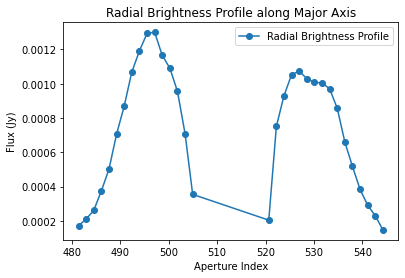

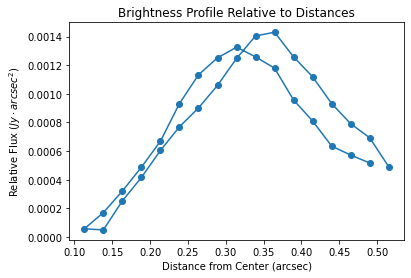

Hmag    0.006527
Name: 0, dtype: float32


In [57]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_SZ_111.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_SZ_111.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_SZ_111.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'SZ 111'
file_path = 'SZ_111_SPHERE_2017-06-18_H.fits'
angle_major_axis = 130  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0003406633533198189


<ipython-input-58-0eead15d1783>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


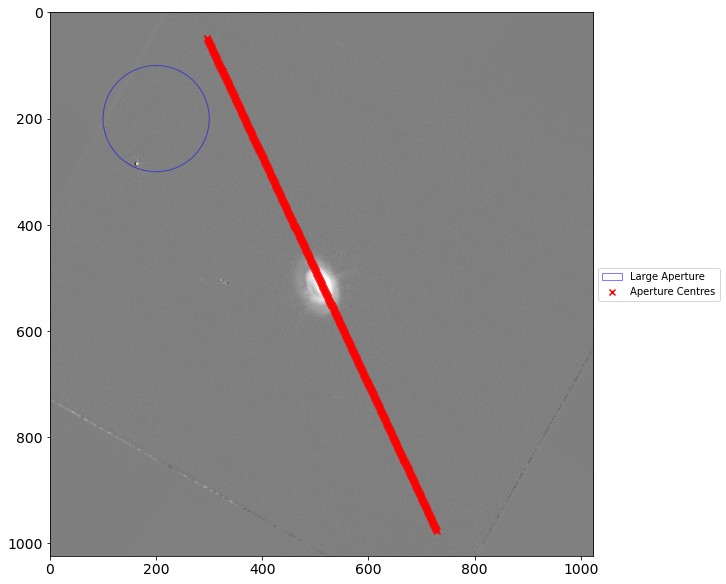

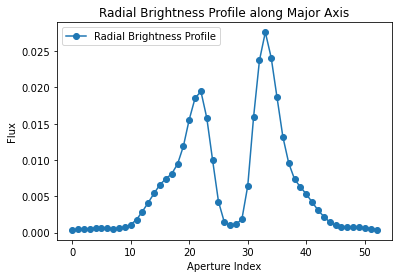

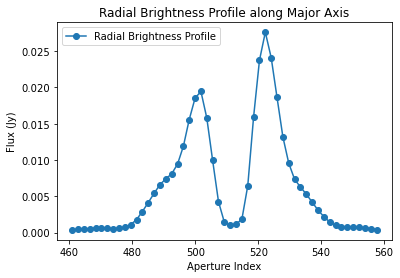

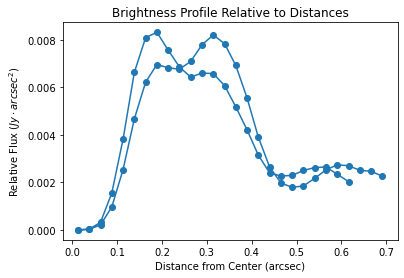

Hmag    0.008859
Name: 0, dtype: float32


In [58]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_SZ_Cha.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_SZ_cha.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_SZ_Cha.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'SZ Cha'
file_path = 'SZCha_SPHERE_2017-03-21_H.fits'
angle_major_axis = 65  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00014500938092347194


<ipython-input-59-748b5fd4fac3>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


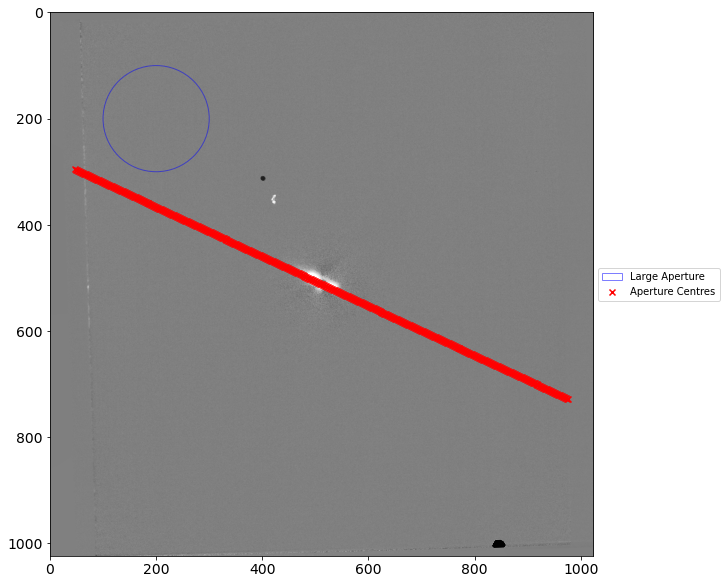

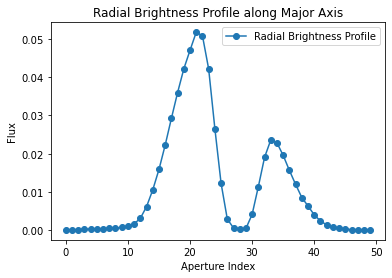

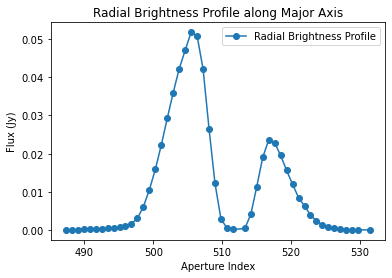

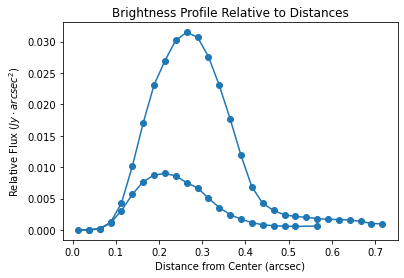

Hmag    0.009841
Name: 0, dtype: float32


In [59]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_T_Cha.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        if dist_arcsec > 5.8:
            continue
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_T_CHa.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        if y < 350:
            continue
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_T_cha.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'T Cha'
file_path = 'T_Cha_SPHERE_2016-02-20_H.fits'
angle_major_axis = 25  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0001350661537705714


<ipython-input-60-8a737b26429c>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


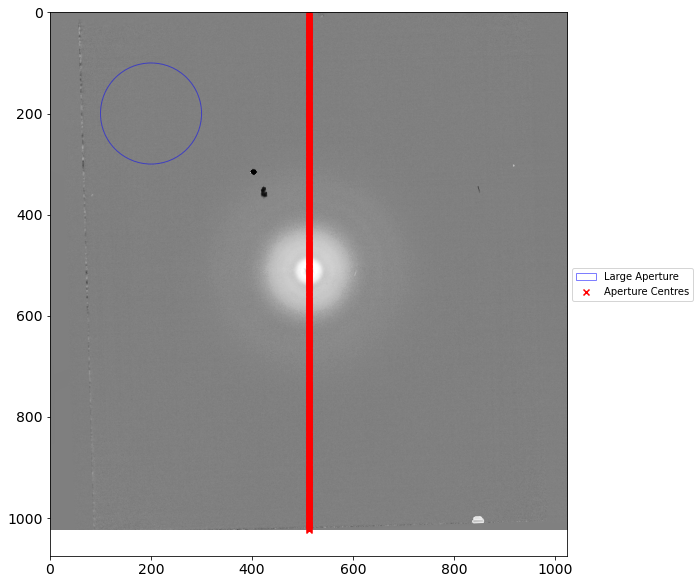

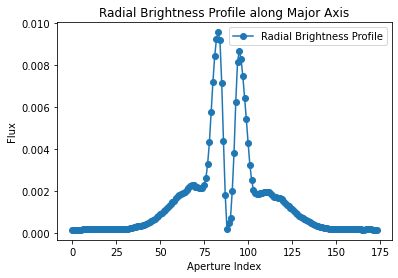

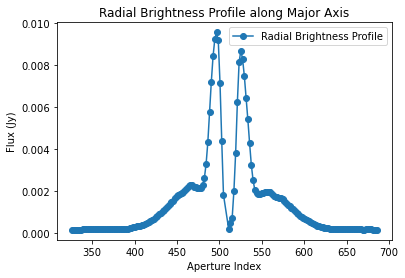

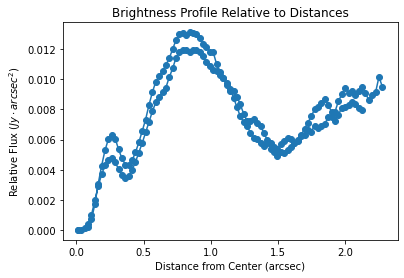

Hmag    0.007739
Name: 0, dtype: float32


In [60]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_TW_Hya.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_TW_Hya.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_TW_Hya.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'TW Hya'
file_path = 'TW_Hya_SPHERE_2015-04-01_H.fits'
angle_major_axis = 90  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00024071008721176623


<ipython-input-61-a22e9cecbeca>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


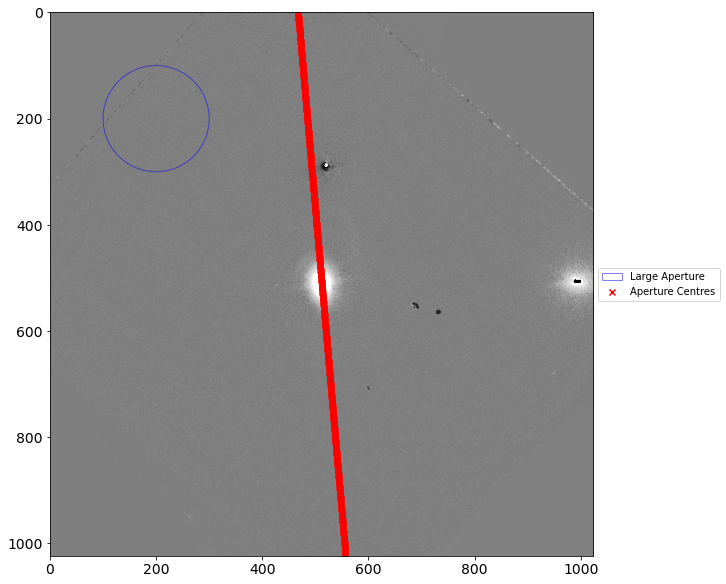

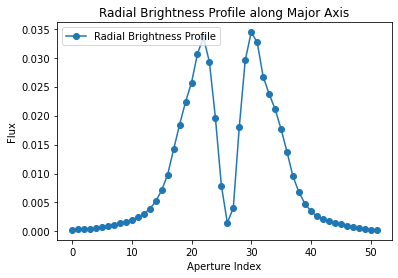

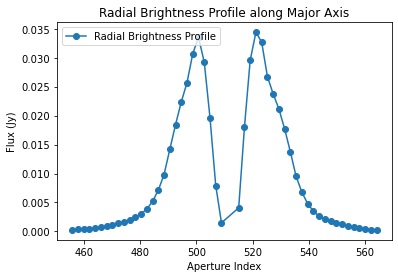

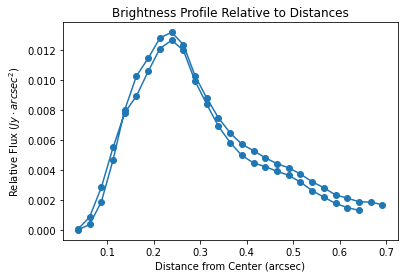

Hmag    0.008369
Name: 0, dtype: float32


In [61]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_UX_tau.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_UX_Tau.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_UX_Tau.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'UX Tau'
file_path = 'UX_Tau_A_SPHERE_2017-10-12_H.fits'
angle_major_axis = 85  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00015682500242455543


<ipython-input-62-162acdc1056d>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


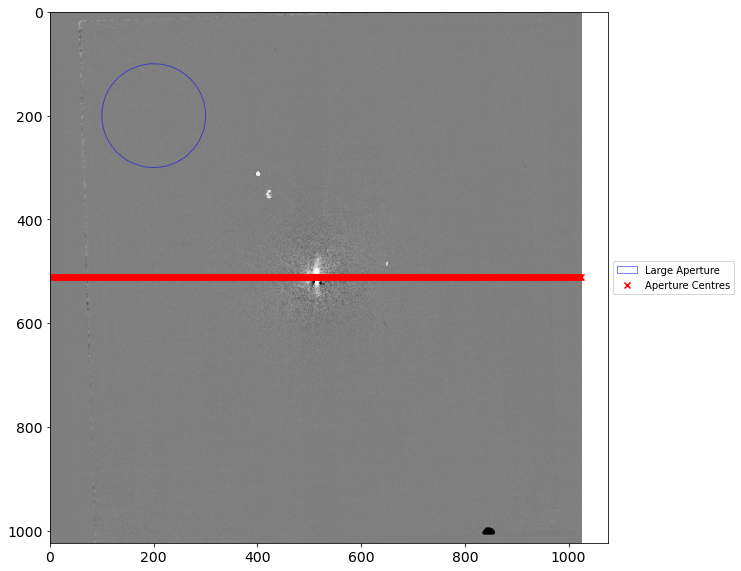

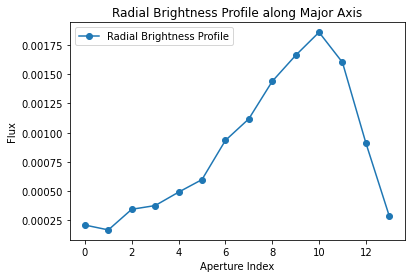

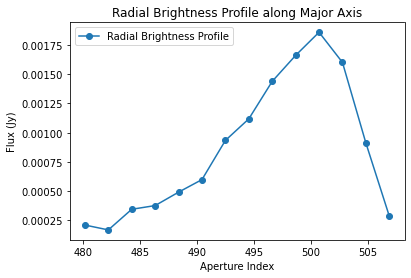

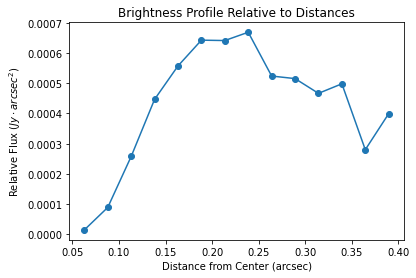

Jmag    0.000327
Name: 0, dtype: float32


In [62]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_V718_Sco.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        if dist_arcsec > 5:
            continue
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_V718_Sco.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        if x < 100:
            continue
        brightness_profile.append(flux)
        aperture_values.append(x)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_V718_Sco.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'V718 Sco'
file_path = 'V718_Sco_SPHERE_2017-06-29_J.fits'
angle_major_axis = 0  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0008879797631296868


<ipython-input-63-5171dfb3c046>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


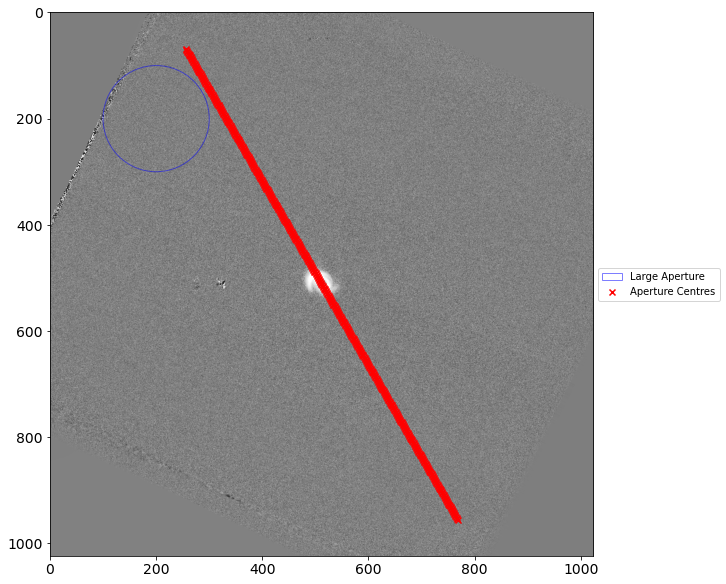

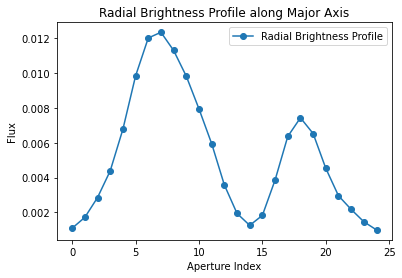

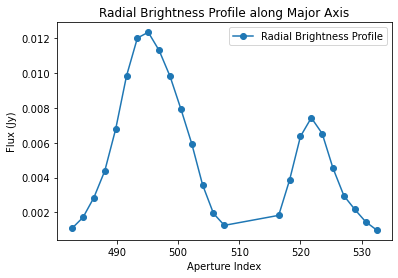

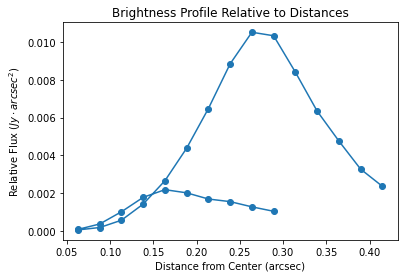

Kmag    0.004624
Name: 0, dtype: float32


In [63]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_V1247_ori.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_V1247_Ori.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_V1247_Ori.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'V1247 Ori'
file_path = 'V1247_Ori_SPHERE_2020-12-20_K.fits'
angle_major_axis = 60  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00019414657542380295


<ipython-input-64-8c5f30fcb24a>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


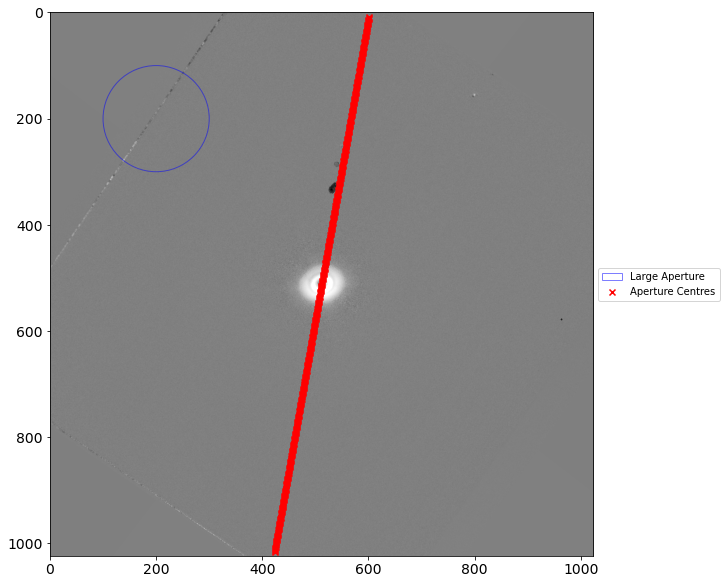

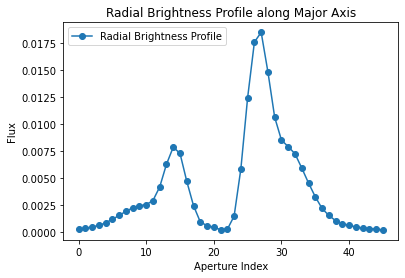

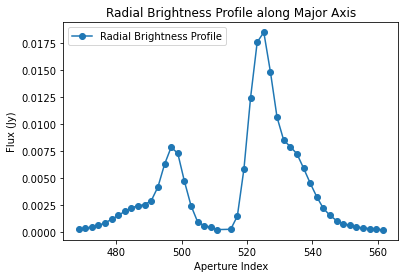

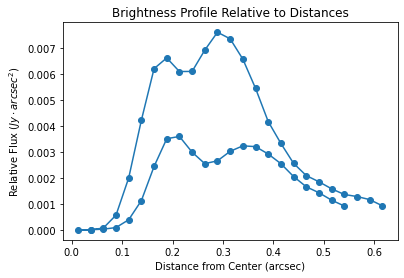

Hmag    0.002551
Name: 0, dtype: float32


In [64]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_V4046_Sgr.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_V4046_Sgr.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_V4046_Sgr.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'V4046 Sgr'
file_path = 'V4046_Sgr_SPHERE_2016-03-14_H.fits'
angle_major_axis = 100  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.0002096990779696516


<ipython-input-65-425efacab01a>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


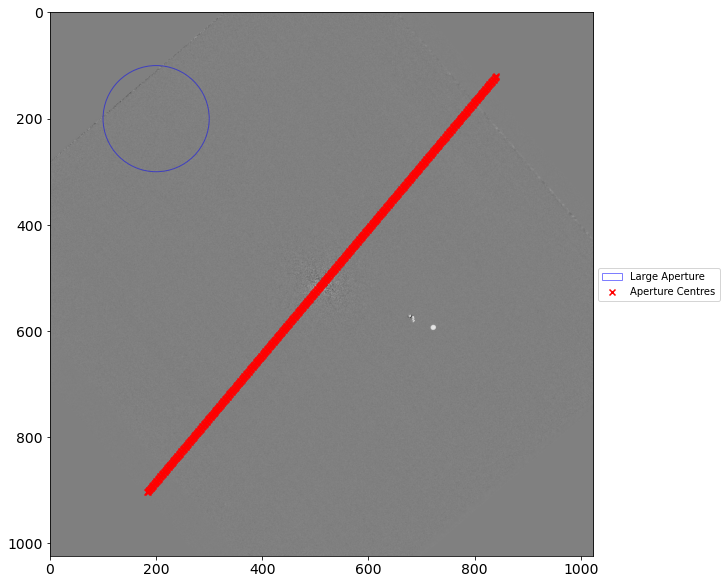

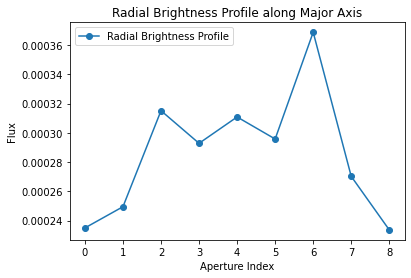

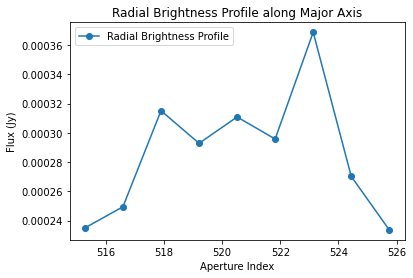

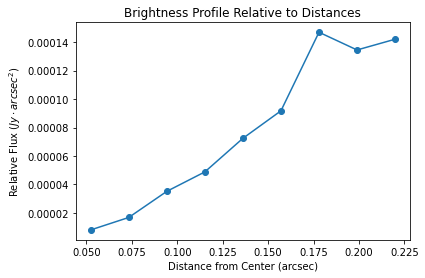

Hmag    0.000366
Name: 0, dtype: float32


In [65]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_VZ_Cha.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_VZ_Cha.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_VZ_Cha.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'VZ Cha'
file_path = 'VZ_Cha_SPHERE_2018-02-28_H.fits'
angle_major_axis = 130  # angle of the major axis
num_apertures = 600
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00015492682861084978


<ipython-input-66-33960649e640>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


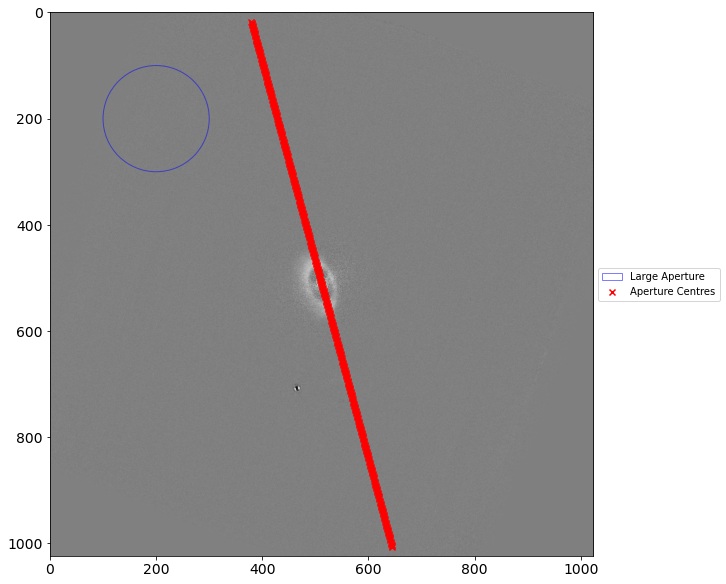

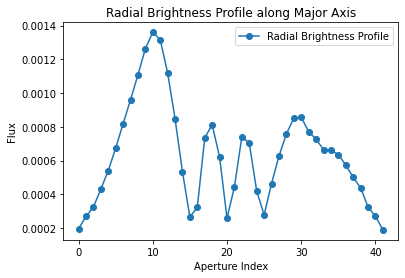

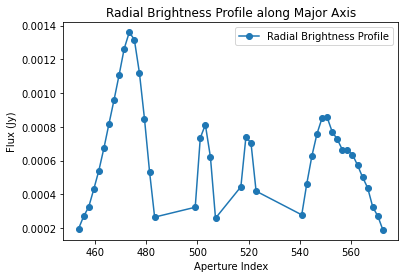

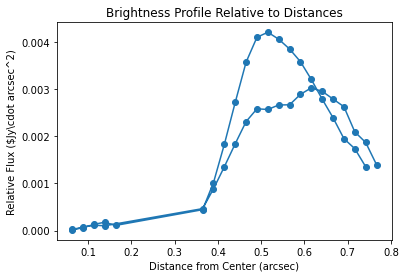

Hmag    0.00635
Name: 0, dtype: float32


In [66]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_PDS_70.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        if dist_arcsec > 2:
            continue
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_PDS_70.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        if y > 650:
            continue
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_PDS_70.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'PDS 70'
file_path = 'PDS_70_SPHERE_2019-08-09_H.fits'
angle_major_axis = 75  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

0.00012842980551207607


<ipython-input-67-331ce80db789>:43: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
  plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))


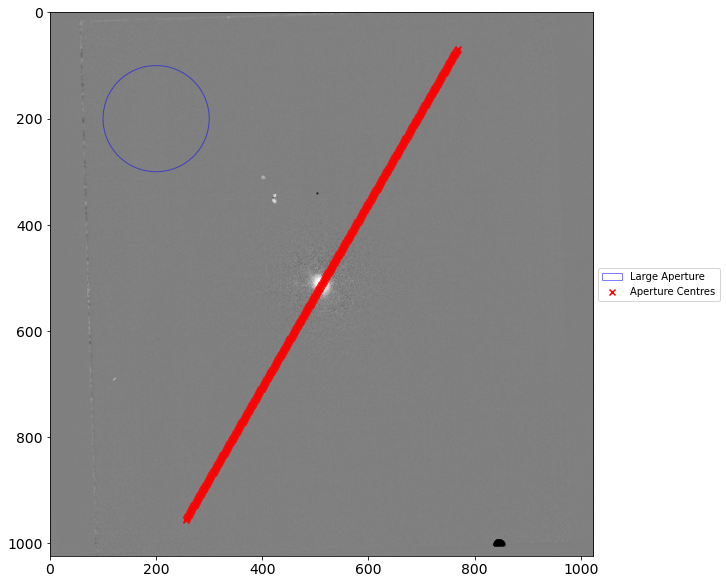

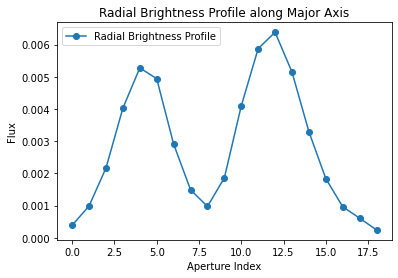

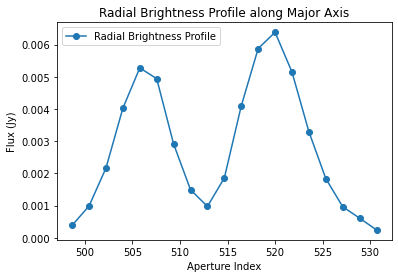

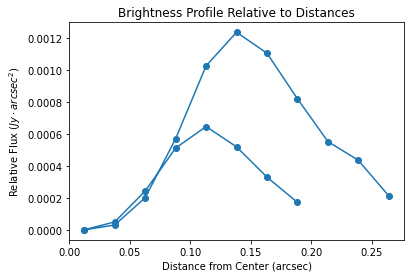

Jmag    0.000604
Name: 0, dtype: float32


In [67]:
# Function 1: Load image from FITS file into a numpy array
def load_image(file_path):
    fits_image = get_pkg_data_filename(file_path)
    image_data = fits.getdata(fits_image, ext=0)
    image = image_data[1]
    return image

# Function 2: Generate aperture coordinates along the major axis
def generate_aperture_coordinates(image, angle_major_axis, num_apertures, lower_left=True):
    # Get the center of the image
    center_y, center_x = np.array(image) / 2.0

    # Convert the angle to radians
    angle_rad = np.radians(angle_major_axis)

    # Generate equally spaced distances along the major axis
    distances = np.linspace(-1, 1, num_apertures)  # Values between -1 and 1 for normalized distances
    distances *= np.max(image) / 2.0  # Scale distances based on image size

    # Calculate coordinates along the specified axis
    x_coordinates = center_x + distances * np.cos(angle_rad)
    y_coordinates = center_y + distances * np.sin(angle_rad)
    
    return x_coordinates, y_coordinates

# Function 3: Perform aperture photometry at a single position
def perform_aperture_photometry(image, x, y, aperture_radius):
    # Define the position for the aperture
    positions = [(x, y)]
    
    # Create a circular aperture centered at the specified position with the given radius
    apertures = CircularAperture(positions, r=aperture_radius)
    
    # Calculate the mean flux within the apertures
    flux = ApertureStats(image, apertures)
    flux_mean = flux.mean
    
    return flux_mean

# Function 4: Visualize the image with apertures
def visualize_image_with_apertures(image, x_coordinates, y_coordinates, large_aperture_x, large_aperture_y, large_aperture_radius):
    plt.figure(figsize=(10,10))
    plt.imshow(image, cmap='gray', norm=SymLogNorm(linthresh=0.001, vmin=-10e-3, vmax=10e-3))
    plt.scatter(x_coordinates, y_coordinates, color='red', marker='x', label='Aperture Centres')
    
    # Plot large aperture in the lower-left region
    large_aperture = CircularAperture([(large_aperture_x, large_aperture_y)], r=large_aperture_radius)
    large_aperture.plot(plt.gca(), color='blue', alpha=0.5, label='Large Aperture')
    
    plt.savefig('image_CV_Cha.jpg')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
# Function 5: Plot the flux of the disk relative to the distance from the centre
def plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise):
    center_y, center_x = np.array(image.shape) / 2.0
    
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)
    
    # Calculate distances from the center for each aperture whose fluxes do not exceed the flux in the large aperture
    distances_from_center = []
    relative_brightness = []

    for x, y in zip(x_coordinates, y_coordinates):
        aperture_flux = perform_aperture_photometry(image, x, y, aperture_radius)
        if aperture_flux < noise:
            continue
        distance_pixel = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        dist_arcsec = distance_pixel * 0.012251
        distances_from_center.append(dist_arcsec)
            
        # Multiply aperture flux by distance and append to the brightness profile list
        rel_flux = aperture_flux * (4 * np.pi * dist_arcsec**2)
        #print(rel_flux)
        relative_brightness.append(rel_flux)
            
    # Convert lists to arrays for plotting
    distances = np.array(distances_from_center)
    rel_brightness = np.array(relative_brightness)
    brightness = np.average(rel_brightness)
            
    # Plot brightness profile relative to distances
    plt.plot(distances, rel_brightness, marker='o', linestyle='-')
    plt.xlabel('Distance from Center (arcsec)')
    plt.ylabel('Relative Flux ($Jy\cdot arcsec^2$)')
    plt.title('Brightness Profile Relative to Distances')
    plt.savefig('rel_brightness_CV_Cha.jpg')
    plt.show()
            
    return brightness

# Function 6: Query the 2MASS catalog for the star flux
def star_mag(star_name, file_path):
    # query 2MASS catalog for the star
    v = Vizier(columns=['*', '_r'], catalog=('II/246/out'))
        
    # query a small region of 2 arcsec around the star to ensure only info for this star is returned
    star_result = v.query_region(star_name, radius='2s')
        
    # return the wise data table for the star
    mass_table = star_result['II/246/out']
        
    # convert the astropy table to a pandas data frame
    df = mass_table.to_pandas()
        
    band_filter = file_path[-6]
    band = band_filter + 'mag'
        
    # extract the 2MASS magnitude from the table
    mag_2mass = df[[band]].iloc[0]
    
    #Values from VIZIER conversion table for filters, matching best 2MASS filter properties
    f0_Y = 2.001e3 #uncertainty of order 0.027e3
    f0_J = 1.562e3 #uncertainty of order 0.017e3
    f0_H = 1.024e3 #uncertainty of order 0.011e3
    f0_K = 6.650e2 #uncertainty of order 0.035e2
        
    if band == "Ymag":
        f_jy = f0_Y * 10**(-0.4*mag_2mass)
    if band == "Jmag":
        f_jy = f0_J * 10**(-0.4*mag_2mass)
    if band == "Hmag":
        f_jy = f0_H * 10**(-0.4*mag_2mass)
    if band == "Kmag":
        f_jy = f0_K * 10**(-0.4*mag_2mass)
    #print(f_jy)
    return f_jy
    
# Master function: Wrapper for functions 1-6
def measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius):
    # Function 1: Load image
    image = load_image(file_path)

    # Function 2: Generate aperture coordinates along the major axis
    x_coordinates, y_coordinates = generate_aperture_coordinates(image.shape, angle_major_axis, num_apertures)

    # Find coordinates of a point in the lower-left region
    lower_left_x, lower_left_y = 200, 200

    # Define a large aperture in the lower-left region
    large_aperture_radius = 100
    aper = CircularAperture((lower_left_x, lower_left_y), large_aperture_radius)
    
    # Calculate the noise within the large aperture
    aperstats = ApertureStats(image, aper)
    noise = 3 * aperstats.std
    print(noise)
    
    # Visualize the image with apertures, including the large aperture
    visualize_image_with_apertures(image, x_coordinates, y_coordinates, lower_left_x, lower_left_y, large_aperture_radius)
    
    # Function 3: Perform aperture photometry and store results along the major axis
    brightness_profile = []
    aperture_values = []
    for x, y in zip(x_coordinates, y_coordinates):
        flux = perform_aperture_photometry(image, x, y, aperture_radius)
        
        # Check if flux equals the noise in the image
        if flux < noise:
            continue
        #else:
        brightness_profile.append(flux)
        aperture_values.append(y)
        
    #print(brightness_profile)

    # Plot radial brightness profile
    plt.plot(brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.show()
    
     # Plot radial brightness profile
    plt.plot(aperture_values, brightness_profile, marker='o', linestyle='-', label='Radial Brightness Profile')
    plt.xlabel('Aperture Index')
    plt.ylabel('Flux (Jy)')
    plt.title('Radial Brightness Profile along Major Axis')
    plt.legend()
    plt.savefig('brightness_profile_CV_Cha.jpg')
    plt.show()
    
    # Plot brightness profile relative to distances
    #plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Brightness of disk
    disk_brightness = plot_brightness_profile(image, angle_major_axis, num_apertures, aperture_radius, noise)
    
    # Find the flux of the star
    star_flux = star_mag(star_name, file_path)
    
    # Calculate the flux of the disk relative to the flux of the star
    rel_flux = disk_brightness / star_flux
    print(rel_flux)
    
    return brightness_profile

# Example usage:
star_name = 'CV Cha'
file_path = 'CV_Cha_SPHERE_2016-03-26_J.fits'
angle_major_axis = 120  # angle of the major axis
num_apertures = 500
aperture_radius = 4  # aperture radius for photometry

brightness_profile = measure_radial_brightness_profile(star_name, file_path, angle_major_axis, num_apertures, aperture_radius)

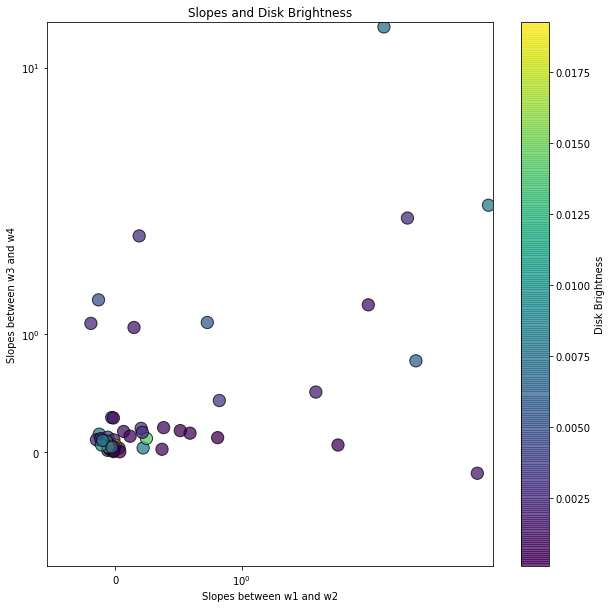

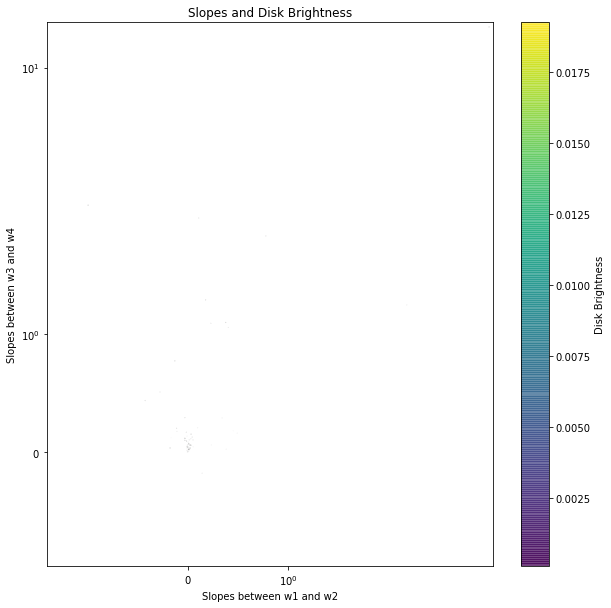

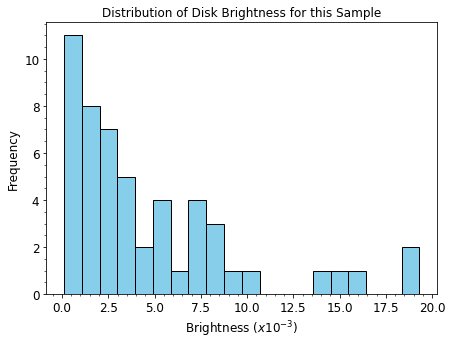

In [70]:
import matplotlib

# Open the data file and read in all the lines
filename = 'list2.txt'
with open(filename) as data:
    lines = data.read().splitlines()

# Define a list to hold the W1-W2 slope
slope_W1W2 = []
# Append the list with the data from the correct column
for line in lines:
    Columns = line.split(' ')
    slope_W1W2.append(Columns[2])

# Define a list to hold the W3-W4 slopes
slope_W3W4 = []
# Append the list with the data from the correct column
for line in lines:
    Columns = line.split(' ')
    slope_W3W4.append(Columns[0])
    
# Define a list to hold the relative disk brightness
brightness_values = []
# Append the list with the data from the correct column
for line in lines:
    Columns = line.split(' ')
    brightness_values.append(Columns[3])
    
stars = []
for line in lines:
    Columns = line.split(' ')
    stars.append(Columns[1])
    
slope_W2W3 = []
for line in lines:
    Columns = line.split(' ')
    slope_W2W3.append(Columns[5])
    
scaled_brightness = []
for line in lines:
    Columns = line.split(' ')
    scaled_brightness.append(Columns[6])
    
#print(slope_W1W2)

# Convert to floats
slope_W1W2 = [float(a) for a in slope_W1W2]
slope_W3W4 = [float(b) for b in slope_W3W4]
slope_W2W3 = [float(d) for d in slope_W2W3]
disk_brightness = [float(c) for c in brightness_values]
scaled_brightness = [float(e) for e in scaled_brightness]

# Create a colormap
#colormap = plt.cm.viridis
#normalize = matplotlib.colors.Normalize()

#print(slope_W1W2)
#print(slope_W3W4)
#print(slope_W2W3)

# Plot
plt.figure(figsize=(10, 10))
plt.scatter(slope_W1W2, slope_W3W4, c=disk_brightness, cmap='viridis', s=150, edgecolors='k', alpha=0.75)
plt.colorbar(label='Disk Brightness')
plt.xlabel('Slopes between w1 and w2')
plt.ylabel('Slopes between w3 and w4')
plt.title('Slopes and Disk Brightness')
plt.xticks(ticks=slope_W1W2, labels=[])
plt.yticks(ticks=slope_W3W4, labels=[])
plt.xscale('symlog')
plt.yscale('symlog')
#plt.xlim([-0.2, 7])
#plt.ylim([-0.2, 20])
#plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(10, 10))
plt.scatter(slope_W2W3, slope_W3W4, c=disk_brightness, cmap='viridis', s=disk_brightness, edgecolors='k', alpha=0.75)
plt.colorbar(label='Disk Brightness')
plt.xlabel('Slopes between w1 and w2')
plt.ylabel('Slopes between w3 and w4')
plt.title('Slopes and Disk Brightness')
plt.xticks(ticks=slope_W2W3, labels=[])
plt.yticks(ticks=slope_W3W4, labels=[])
plt.xscale('symlog')
plt.yscale('symlog')
#plt.xlim([-0.2, 7])
#plt.ylim([-0.2, 20])
#plt.tight_layout()
plt.show()

# Histogram of brightness
# Data for histogram
data = scaled_brightness

#Plotting basic histogram
plt.figure(figsize=(7, 5))
plt.hist(data, bins=20, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Brightness ($x10^{-3}$)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Disk Brightness for this Sample')
plt.minorticks_on()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('histogram.jpg')
plt.show()

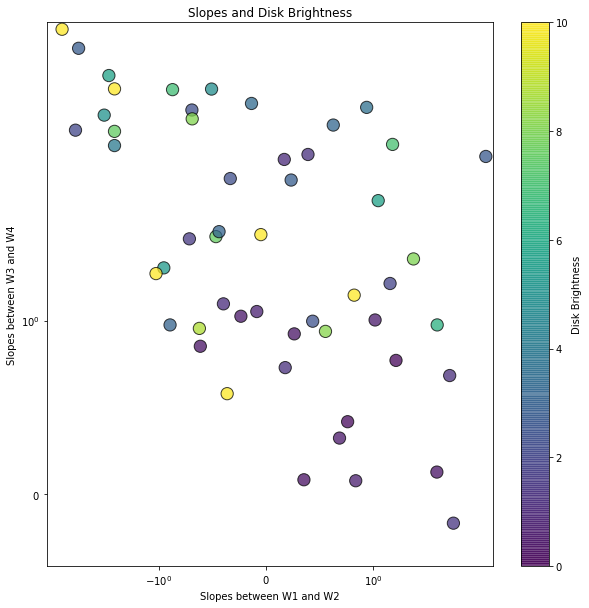

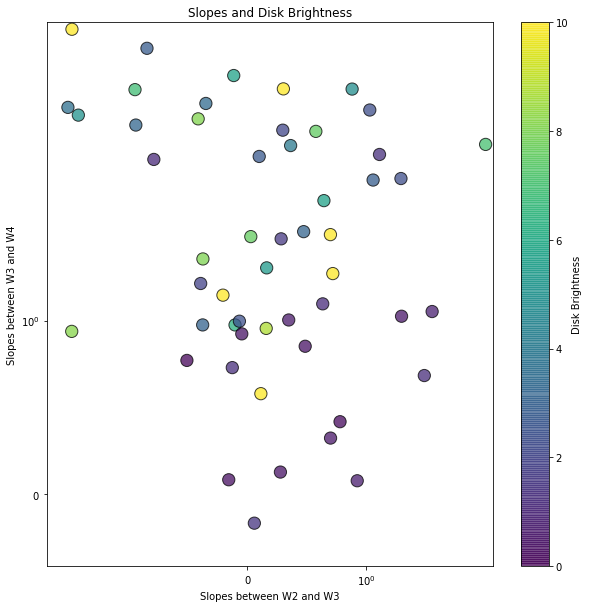

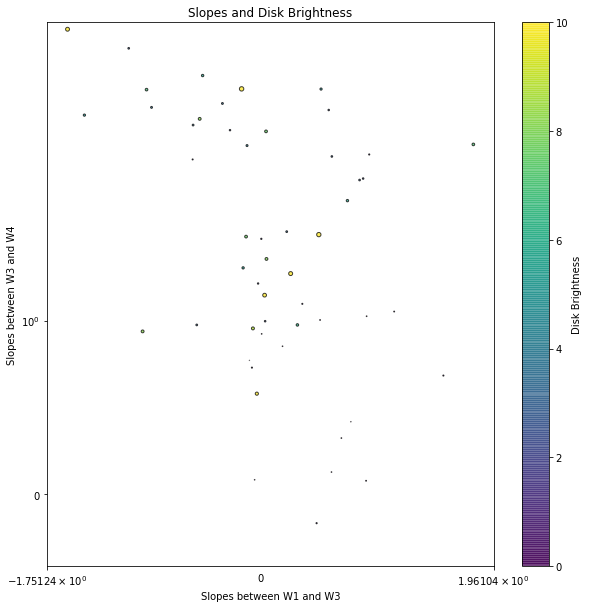

In [71]:
import matplotlib

# Open the data file and read in all the lines
filename1 = 'list2.txt'
with open(filename1) as data:
    lines1 = data.read().splitlines()
    
# Define a list to hold the scaled relative disk brightness
scaled_brightness = []
for line in lines:
    Columns = line.split(' ')
    scaled_brightness.append(Columns[6])

# Open the data file and read in all the lines
filename2 = 'slopes.txt'
with open(filename2) as data:
    lines2 = data.read().splitlines()

# Define a list to hold the W1-W2 slope
slope_W1W2 = []
# Append the list with the data from the correct column
for line in lines2:
    Columns = line.split(' ')
    slope_W1W2.append(Columns[0])

# Define a list to hold the W3-W4 slopes
slope_W3W4 = []
# Append the list with the data from the correct column
for line in lines2:
    Columns = line.split(' ')
    slope_W3W4.append(Columns[1])
    
slope_W2W3 = []
for line in lines2:
    Columns = line.split(' ')
    slope_W2W3.append(Columns[2])
    
slope_W1W3 = []
for line in lines2:
    Columns = line.split(' ')
    slope_W1W3.append(Columns[3])
    
#print(slope_W1W2)

# Convert to floats
slope_W1W2 = [float(a) for a in slope_W1W2]
slope_W3W4 = [float(b) for b in slope_W3W4]
slope_W2W3 = [float(d) for d in slope_W2W3]
slope_W1W3 = [float(f) for f in slope_W1W3]
disk_brightness = [float(c) for c in brightness_values]
scaled_brightness = [float(e) for e in scaled_brightness]

# Plot
plt.figure(figsize=(10, 10))
plt.scatter(slope_W1W2, slope_W3W4, c=scaled_brightness, cmap='viridis', s=150, edgecolors='k', alpha=0.75)
plt.colorbar(label='Disk Brightness')
plt.xlabel('Slopes between W1 and W2')
plt.ylabel('Slopes between W3 and W4')
plt.title('Slopes and Disk Brightness')
plt.xticks(ticks=slope_W1W2, labels=[])
plt.yticks(ticks=slope_W3W4, labels=[])
plt.xscale('symlog')
plt.yscale('symlog')
plt.clim(0, 10)
#plt.xlim([-0.2, 7])
#plt.ylim([-0.2, 20])
#plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(10, 10))
plt.scatter(slope_W2W3, slope_W3W4, c=scaled_brightness, cmap='viridis', s=150, edgecolors='k', alpha=0.75)
plt.colorbar(label='Disk Brightness')
plt.xlabel('Slopes between W2 and W3')
plt.ylabel('Slopes between W3 and W4')
plt.title('Slopes and Disk Brightness')
plt.xticks(ticks=slope_W2W3, labels=[])
plt.yticks(ticks=slope_W3W4, labels=[])
plt.xscale('symlog')
plt.yscale('symlog')
plt.clim(0, 10)
#plt.xlim([-0.2, 7])
#plt.ylim([-0.2, 20])
#plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(10, 10))
plt.scatter(slope_W1W3, slope_W3W4, c=scaled_brightness, cmap='viridis', s=scaled_brightness, edgecolors='k', alpha=0.75)
plt.colorbar(label='Disk Brightness')
plt.xlabel('Slopes between W1 and W3')
plt.ylabel('Slopes between W3 and W4')
plt.title('Slopes and Disk Brightness')
plt.xticks(ticks=slope_W1W3, labels=slope_W1W3)
plt.yticks(ticks=slope_W3W4, labels=slope_W3W4)
plt.xscale('symlog')
plt.yscale('symlog')
plt.clim(0, 10)
plt.minorticks_on()
# Annotate zero point
plt.text(0, -0.5, '0')
#plt.grid()
plt.show()

VizieR Query Version 2
==

The second version will be for the second part of the project where we want to find new interesting systems to observe. Here we will not know the stellar name, but rather we will have several constraints that we want to query the catalog for. The first set of constraints will be related to the observability of the stellar system with the VLT and the SPHERE instrument. For that the declination of the star needs to be smaller than 30 deg (visible from the southern hemisphere). The G magnitude of the system (that is the Gaia magnitude from the Gaia satellite mission), should be smaller than 13.5 mag (remember smaller magnitude means brighter star). That is so that the central star in the system is bright enough at short optical wavelengths to feed the adaptive optics system. Finally we want the stars to be close enough so that we can resolve the disks. This means ideally within 200 pc but we can go out to 500 pc to really capture everything remotely interesting. In the catalogs you will likely not find the distance but rather the parallax which relates to the distance like: distance[pc] = 1000/parallax[mas]. Once all these constraints are met we then want to check which of these systems meet the WISE criteria that you found for having a bright disk.

* DE_ICRS < 30 deg
* Gmag < 13.5 (not in WISE catalog, can we query this just through VizieR or do we need Gaia catalog)
* Distance > 200 pc, < 500 pc -> parallax (also from Gaia catalog) = 1000/distance(pc) -> Plx between 2 and 5
* Print these systems, check their WISE flux ratios or filter systems by WISE flux ratios for bright disks
Find their WISE slopes and plot on graph

In [72]:
#gaia_result = Vizier(catalog='I/345/gaia2', row_limit=100000).query_constraints(DE_ICRS='<30')
#print(gaia_result)

gaia_result = Vizier(catalog='I/345/gaia2', row_limit=1000, columns=['*', '_RAJ2000', '_DEJ2000']).query_constraints(DEJ2000='<30', Gmag='<13.5', Plx= '2.0..5.0')[0]
 
#print(gaia_result)

In [73]:
# add column_filters for W1_mag, W2_mag, W3_mag, W4_mag
wise_result = Vizier(catalog='II/311/wise', row_limit=1000000).query_region(gaia_result, radius="2s")[0]
print(wise_result)

 _q         WISE         RAJ2000    DEJ2000   eeMaj  ...  ex var   d2M   _2M
                           deg        deg     arcsec ...          arcsec    
--- ------------------- ---------- ---------- ------ ... --- ---- ------ ---
  1 J071708.43-370551.3 109.285158 -37.097589  0.050 ...   1 nnnn  1.314  2M
  2 J194615.52+103648.5 296.564673  10.613490  0.073 ...   1 nnnn  1.282  2M
  4 J053243.84-174919.0  83.182688 -17.821952  0.028 ...   1 nn95  0.887  2M
  6 J001314.07+151101.1   3.308625  15.183665  0.108 ...   1 2091  1.167  2M
  9 J074917.68-245134.4 117.323687 -24.859568  0.044 ...   1 nn99  0.602  2M
 10 J165152.19-380250.6 252.967488 -38.047410  0.040 ...   1 4099  0.485  2M
 11 J053212.78+183540.1  83.053273  18.594495  0.046 ...   1 nnnn  0.813  2M
 13 J172523.64-562239.9 261.348526 -56.377756  0.077 ...   0 0000  0.554  2M
 15 J100720.02+164545.6 151.833453  16.762694  0.062 ...   1 1n20  1.163  2M
 17 J095651.72-543404.2 149.215538 -54.567837  0.071 ...   1 0110  0.084  2M